# GD07. Mini BERT Pretraining

## 프로젝트 목표 👩‍🔬

Transformer Encoder 기반의 BERT pretraining 과정을 직접 구현한다.

한글 코퍼스를 SentencePiece로 토큰화한 뒤,
BERT의 두 가지 사전학습 task인 MLM(Masked Language Modeling)과
NSP(Next Sentence Prediction)를 위한 데이터셋을 생성한다.

이후 약 1M parameter 규모의 mini BERT를 구성하고
10 epoch 동안 pretraining하여 MLM/NSP loss의 변화를 관찰한다.

---

## 전체 실험 흐름

```text
Korean Wiki Corpus
        │
        ▼
SentencePiece BPE
vocab ≈ 8,000
        │
        ▼
Token Sequence
        │
        ├──────────────┐
        │              │
        ▼              ▼
      MLM             NSP
 15% token 선택    Sentence A/B
 80/10/10         TRUE/FALSE
        │              │
        └──────┬───────┘
               ▼
      BERT Pretrain Dataset
               │
               ▼
 Token + Position + Segment
          Embedding
               │
               ▼
      Transformer Encoder
               │
        ┌──────┴──────┐
        ▼             ▼
     MLM Head       NSP Head
        │             │
     MLM Loss       NSP Loss
        └──────┬──────┘
               ▼
       Backpropagation
               │
               ▼
        Mini BERT (~1M)
               │
               ▼
          10 Epochs
               │
               ▼
       Loss / Accuracy
         Visualization

In [2]:
!nvidia-smi

Mon Sep 14 07:06:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
%pip install -q sentencepiece torchinfo

In [6]:
# ============================================================
# STEP 0-3. Imports & Seed
# ============================================================

import os
import re
import math
import json
import random
import shutil
import zipfile
import collections
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
from tqdm.auto import tqdm

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)
print("Seed   :", SEED)

Device : cuda
Seed   : 1234


# STEP 1. Korean Wiki Corpus 준비

## 이번 단계의 질문

> BERT는 무엇을 보고 언어를 배우는가?

BERT pretraining에는 사람이 직접
`긍정 / 부정`, `고양이 / 강아지`처럼 label을 붙여주지 않는다.

대신 대량의 자연어 문장에서 일부 정보를 숨기거나
문장 관계를 변형하여 모델 스스로 정답을 만들 수 있게 한다.

```text
대량의 자연어
     │
     ▼
정답 없는 raw corpus
     │
     ├─ 일부 단어를 숨김 → MLM 정답 생성
     │
     └─ 문장 관계를 변경 → NSP 정답 생성
     │
     ▼
Self-supervised Learning

In [7]:
# ============================================================
# STEP 1-1. Korean Wiki corpus 다운로드
# ============================================================

DATA_URL = (
    "https://d3s0tskafalll9.cloudfront.net/"
    "media/documents/kowiki.txt.zip"
)

ZIP_PATH = RUNTIME_DATA_DIR / "kowiki.txt.zip"
CORPUS_PATH = RUNTIME_DATA_DIR / "kowiki.txt"

if CORPUS_PATH.exists():
    print("이미 압축 해제된 corpus가 있습니다.")
    print(CORPUS_PATH)

else:
    if not ZIP_PATH.exists():
        print("Korean Wiki corpus 다운로드 시작...")
        !wget -c -O "{ZIP_PATH}" "{DATA_URL}"
    else:
        print("기존 zip 파일을 사용합니다.")

    print("\n압축 해제...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        print("ZIP contents:", zf.namelist())
        zf.extractall(RUNTIME_DATA_DIR)

print("\nCorpus ready:", CORPUS_PATH.exists())

Korean Wiki corpus 다운로드 시작...
--2026-09-14 07:08:10--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.118, 13.249.182.60, 13.249.182.14, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13.249.182.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘/content/GD07_BERT/data/kowiki.txt.zip’

/content/GD07_BERT/ 100%[===================>] 231.86M  27.8MB/s    in 9.0s    

2026-09-14 07:08:19 (25.8 MB/s) - ‘/content/GD07_BERT/data/kowiki.txt.zip’ saved [243123354/243123354]


압축 해제...
ZIP contents: ['kowiki.txt']

Corpus ready: True


In [8]:
# 집파일 괜시리 용량만 차지하니까 삭제
if ZIP_PATH.exists() and CORPUS_PATH.exists():
    zip_size = ZIP_PATH.stat().st_size / 1024**2
    ZIP_PATH.unlink()
    print(f"압축 해제 완료 → zip 삭제 ({zip_size:.1f} MB 회수)")

압축 해제 완료 → zip 삭제 (231.9 MB 회수)


## Corpus sanity check

모델 학습 전에 데이터 자체를 먼저 확인한다.
- corpus 파일이 실제 생성되었는가
- 파일 크기는 어느 정도인가
- 문장이 정상적인 한글 텍스트인가

- 빈 파일이나 HTML 등의 잘못된 데이터가 아닌가

딥러닝 파이프라인에서:

```text
Raw Data
   │
   ▼
검증 ───────────────┐
   │               │
   │ 문제가 없다면    │ 문제가 있다면
   ▼               ▼
전처리              수정
   │
   ▼
Model

In [9]:
# ============================================================
# STEP 1-2. Corpus sanity check
# ============================================================

assert CORPUS_PATH.exists(), "kowiki.txt가 없습니다."

size_mb = CORPUS_PATH.stat().st_size / (1024**2)

print(f"Corpus path : {CORPUS_PATH}")
print(f"File size   : {size_mb:,.2f} MB")

print("\n--- Sample ---")

with CORPUS_PATH.open("r", encoding="utf-8") as f:
    for i in range(5):
        line = f.readline().strip()
        print(f"[{i}] {line[:300]}")

Corpus path : /content/GD07_BERT/data/kowiki.txt
File size   : 635.67 MB

--- Sample ---
[0] 지미 카터
[1] 제임스 얼 "지미" 카터 주니어(, 1924년 10월 1일 ~ )는 민주당 출신 미국 39번째 대통령 (1977년 ~ 1981년)이다.
[2] 지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.
[3] 1962년 조지아 주 상원 의원 선거에서 낙선하나 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주 지사 선거에 낙선하지만 1970년 조지아 주 지사를 역임했다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.
[4] 1976년 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워, 포드를 누르고 당선되었다.


# STEP 2. SentencePiece BPE Tokenizer

## 이번 단계의 질문

> 모델은 한국어 문장을 그대로 읽을 수 없는데,
> 텍스트를 어떻게 BERT가 처리할 수 있는 숫자로 바꿀까?

신경망은 문자열 자체를 입력으로 계산하지 않는다.

따라서 다음 변환이 필요하다.

```text
한국어 문장
    │
    ▼
SentencePiece
    │
    ▼
Subword Token
    │
    ▼
Vocabulary ID
    │
    ▼
정수 Sequence
    │
    ▼
Embedding Vector
    │
    ▼
BERT

In [11]:
# ============================================================
# STEP 2-1. SentencePiece 환경 및 tokenizer 설정
# ============================================================

import os
import sentencepiece as spm

print("SentencePiece version :", spm.__version__)

BASE_VOCAB_SIZE = 8000

SPECIAL_TOKENS = {
    "[PAD]": 0,
    "[UNK]": 1,
    "[BOS]": 2,
    "[EOS]": 3,
    "[SEP]": 4,
    "[CLS]": 5,
    "[MASK]": 6,
}

# LMS 원본의 설계:
# 일반 BPE vocabulary + 7개 special tokens
TOTAL_VOCAB_SIZE = BASE_VOCAB_SIZE + len(SPECIAL_TOKENS)

print("Base vocabulary :", BASE_VOCAB_SIZE)
print("Special tokens  :", len(SPECIAL_TOKENS))
print("Expected pieces :", TOTAL_VOCAB_SIZE)

SentencePiece version : 0.2.2
Base vocabulary : 8000
Special tokens  : 7
Expected pieces : 8007


## Tokenizer 학습 데이터와 BERT 학습 데이터는 다르다!

여기서 `SentencePiece를 학습한다`와
`BERT를 학습한다`를 구분해야 한다.

```text
SentencePiece Training
────────────────────────
목적 : 어떤 subword로 문장을 쪼갤지 학습

입력 : raw Korean corpus
출력 : ko_8000.model
       ko_8000.vocab


BERT Pretraining
────────────────────────
목적 : 토큰 사이의 문맥 관계를 학습

입력 : tokenizer로 변환된 sequence
       + MLM
       + NSP

출력 : BERT model parameters

In [12]:
# ============================================================
# STEP 2-3. SentencePiece BPE tokenizer 학습
# ============================================================

TOKENIZER_NAME = "ko_8000"

RUNTIME_TOKENIZER_PREFIX = RUNTIME_MODEL_DIR / TOKENIZER_NAME

RUNTIME_TOKENIZER_MODEL = Path(
    str(RUNTIME_TOKENIZER_PREFIX) + ".model"
)
RUNTIME_TOKENIZER_VOCAB = Path(
    str(RUNTIME_TOKENIZER_PREFIX) + ".vocab"
)

DRIVE_TOKENIZER_MODEL = DRIVE_TOKENIZER_DIR / f"{TOKENIZER_NAME}.model"
DRIVE_TOKENIZER_VOCAB = DRIVE_TOKENIZER_DIR / f"{TOKENIZER_NAME}.vocab"


# ------------------------------------------------------------
# 1. Drive checkpoint가 이미 존재하면 복구
# ------------------------------------------------------------
if DRIVE_TOKENIZER_MODEL.exists() and DRIVE_TOKENIZER_VOCAB.exists():

    print("[Checkpoint] 기존 tokenizer 발견")
    print("→ Runtime으로 복사합니다.")

    shutil.copy2(
        DRIVE_TOKENIZER_MODEL,
        RUNTIME_TOKENIZER_MODEL,
    )

    shutil.copy2(
        DRIVE_TOKENIZER_VOCAB,
        RUNTIME_TOKENIZER_VOCAB,
    )


# ------------------------------------------------------------
# 2. 없으면 새로 학습
# ------------------------------------------------------------
else:

    print("[Train] SentencePiece BPE tokenizer 학습 시작")
    print(f"Corpus        : {CORPUS_PATH}")
    print(f"Base vocab    : {BASE_VOCAB_SIZE}")
    print(f"Total pieces  : {TOTAL_VOCAB_SIZE}")

    spm.SentencePieceTrainer.train(

        input=str(CORPUS_PATH),
        model_prefix=str(RUNTIME_TOKENIZER_PREFIX),

        # LMS 원본과 동일하게 BPE
        model_type="bpe",

        # 일반 vocab 8000 + special token 7
        vocab_size=TOTAL_VOCAB_SIZE,

        # 한국어/한자 등이 포함된 corpus
        character_coverage=0.9995,

        # Colab RAM 보호:
        # 전체 395만 줄 중 최대 100만 문장을 샘플링
        input_sentence_size=1_000_000,
        shuffle_input_sentence=True,

        # LMS 원본의 긴 문장 허용 설정 유지
        max_sentence_length=999999,

        # special tokens
        pad_id=0,
        pad_piece="[PAD]",

        unk_id=1,
        unk_piece="[UNK]",

        bos_id=2,
        bos_piece="[BOS]",

        eos_id=3,
        eos_piece="[EOS]",

        user_defined_symbols=[
            "[SEP]",
            "[CLS]",
            "[MASK]",
        ],

        # 가능한 한 요청한 vocab 크기를 정확히 생성
        hard_vocab_limit=True,

        # CPU 활용
        num_threads=max(1, os.cpu_count() or 1),
    )

    print("\nTokenizer training complete.")


    # --------------------------------------------------------
    # 성공 직후 Drive checkpoint 저장
    # --------------------------------------------------------
    shutil.copy2(
        RUNTIME_TOKENIZER_MODEL,
        DRIVE_TOKENIZER_MODEL,
    )

    shutil.copy2(
        RUNTIME_TOKENIZER_VOCAB,
        DRIVE_TOKENIZER_VOCAB,
    )

    print("\n[Checkpoint saved]")
    print(DRIVE_TOKENIZER_MODEL)
    print(DRIVE_TOKENIZER_VOCAB)

[Train] SentencePiece BPE tokenizer 학습 시작
Corpus        : /content/GD07_BERT/data/kowiki.txt
Base vocab    : 8000
Total pieces  : 8007

Tokenizer training complete.

[Checkpoint saved]
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/GD07/tokenizer/ko_8000.model
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/GD07/tokenizer/ko_8000.vocab


## Tokenizer 검증

```text
Tokenizer 생성
     │
     ▼
총 vocabulary 크기 확인
     │
     ▼
Special Token ID 확인
     │
     ▼
실제 한국어 문장 Encode
     │
     ▼
Token ↔ ID 변환 확인

In [13]:
# ============================================================
# STEP 2-4. Tokenizer 검증
# ============================================================

vocab = spm.SentencePieceProcessor()

loaded = vocab.load(str(RUNTIME_TOKENIZER_MODEL))
assert loaded, "SentencePiece model loading failed."

actual_vocab_size = vocab.get_piece_size()

print("=" * 70)
print("Tokenizer Validation")
print("=" * 70)

print(f"Expected piece size : {TOTAL_VOCAB_SIZE}")
print(f"Actual piece size   : {actual_vocab_size}")

assert actual_vocab_size == TOTAL_VOCAB_SIZE, (
    f"Vocabulary size mismatch: "
    f"{actual_vocab_size} != {TOTAL_VOCAB_SIZE}"
)

print("\n[Special Token IDs]")

for token, expected_id in SPECIAL_TOKENS.items():

    actual_id = vocab.piece_to_id(token)

    status = (
        "OK"
        if actual_id == expected_id
        else "CHECK"
    )

    print(
        f"{token:8s} "
        f"expected={expected_id:<2d} "
        f"actual={actual_id:<2d} "
        f"[{status}]"
    )

Tokenizer Validation
Expected piece size : 8007
Actual piece size   : 8007

[Special Token IDs]
[PAD]    expected=0  actual=0  [OK]
[UNK]    expected=1  actual=1  [OK]
[BOS]    expected=2  actual=2  [OK]
[EOS]    expected=3  actual=3  [OK]
[SEP]    expected=4  actual=4  [OK]
[CLS]    expected=5  actual=5  [OK]
[MASK]   expected=6  actual=6  [OK]


In [14]:
# ============================================================
# STEP 2-5. Tokenization sample
# ============================================================

sample_texts = [
    "나는 오늘 BERT 사전학습을 공부한다.",
    "인공지능 모델은 문맥에 따라 단어의 의미를 다르게 표현한다.",
    "트랜스포머는 셀프 어텐션을 이용해 토큰 사이의 관계를 계산한다.",
]

for text in sample_texts:

    pieces = vocab.encode(
        text,
        out_type=str,
    )

    ids = vocab.encode(
        text,
        out_type=int,
    )

    decoded = vocab.decode(ids)

    print("=" * 70)
    print("TEXT   :", text)
    print("PIECES :", pieces)
    print("IDS    :", ids)
    print("DECODE :", decoded)

TEXT   : 나는 오늘 BERT 사전학습을 공부한다.
PIECES : ['▁나', '는', '▁오늘', '▁B', 'E', 'R', 'T', '▁사', '전', '학', '습', '을', '▁공부', '한다', '.']
IDS    : [57, 3614, 1595, 395, 3910, 3936, 3851, 15, 3652, 3697, 4018, 3619, 3477, 69, 3611]
DECODE : 나는 오늘 BERT 사전학습을 공부한다.
TEXT   : 인공지능 모델은 문맥에 따라 단어의 의미를 다르게 표현한다.
PIECES : ['▁인', '공', '지', '능', '▁모델', '은', '▁문', '맥', '에', '▁따라', '▁단', '어의', '▁의미', '를', '▁다', '르게', '▁표현', '한다', '.']
IDS    : [42, 3682, 3622, 3925, 1261, 3625, 117, 4172, 3612, 274, 166, 1465, 627, 3636, 29, 1569, 999, 69, 3611]
DECODE : 인공지능 모델은 문맥에 따라 단어의 의미를 다르게 표현한다.
TEXT   : 트랜스포머는 셀프 어텐션을 이용해 토큰 사이의 관계를 계산한다.
PIECES : ['▁트', '랜', '스', '포', '머', '는', '▁셀', '프', '▁어', '텐', '션', '을', '▁이용', '해', '▁토', '큰', '▁사이의', '▁관계를', '▁계산', '한다', '.']
IDS    : [444, 3994, 3639, 3761, 3970, 3614, 2984, 3733, 134, 4283, 4008, 3619, 508, 3657, 362, 4059, 1925, 2744, 2820, 69, 3611]
DECODE : 트랜스포머는 셀프 어텐션을 이용해 토큰 사이의 관계를 계산한다.


In [15]:
# ============================================================
# STEP 2-6. Tokenizer metadata 저장
# ============================================================

tokenizer_metadata = {

    "project": "GD07 Mini BERT",

    "tokenizer": {
        "library": "sentencepiece",
        "version": spm.__version__,
        "model_type": "bpe",

        "base_vocab_size": BASE_VOCAB_SIZE,
        "special_token_count": len(SPECIAL_TOKENS),
        "actual_piece_size": vocab.get_piece_size(),

        "special_tokens": {
            token: vocab.piece_to_id(token)
            for token in SPECIAL_TOKENS
        },
    },

    "corpus": {
        "path_runtime": str(CORPUS_PATH),
        "size_mb": round(
            CORPUS_PATH.stat().st_size / 1024**2,
            2,
        ),
        "tokenizer_input_sentence_size": 1_000_000,
    },

    "seed": SEED,
}

TOKENIZER_META_PATH = (
    DRIVE_OUTPUT_DIR /
    "tokenizer_metadata.json"
)

with open(
    TOKENIZER_META_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        tokenizer_metadata,
        f,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:", TOKENIZER_META_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/GD07/tokenizer_metadata.json


# STEP 3. MLM — Masked Language Modeling

## 이번 단계의 질문

> 정답이 없는 Wiki 문장만 가지고
> 어떻게 모델에게 "맞혀야 할 문제"를 만들어 줄까?

BERT는 사람이 직접 label을 붙이지 않아도
원래 문장의 일부를 숨기고 그 원래 값을 정답으로 사용한다.

이를 **Masked Language Modeling (MLM)** 이라고 한다.

```text
원래 문장
나는 오늘 학교에 간다
        │
        │ 일부 토큰 선택
        ▼
나는 오늘 [MASK] 간다
        │
        ├─ 입력  : [MASK]
        └─ 정답  : 학교에

In [16]:
# ============================================================
# STEP 3-1. 실제 Wiki 문장을 MLM 예제로 준비
# ============================================================

sample_sentence = None

with CORPUS_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # 너무 짧은 제목보다 문장 형태가 있는 sample 선택
        if len(line) >= 80:
            sample_sentence = line
            break

assert sample_sentence is not None

sample_sentence = sample_sentence[:300]

sample_pieces = vocab.encode(
    sample_sentence,
    out_type=str,
)

# BERT 입력 형태를 보기 위해 special token 추가
tokens_org = (
    ["[CLS]"]
    + sample_pieces
    + ["[SEP]"]
)

print("RAW TEXT")
print(sample_sentence)

print("\nTOKEN COUNT:", len(tokens_org))

print("\nTOKENS")
print(tokens_org)

RAW TEXT
지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다. 조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.

TOKEN COUNT: 101

TOKENS
['[CLS]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]']


## Subword와 Whole-word 단위 masking

SentencePiece는 단어 시작 위치에 `▁`를 붙인다.

예를 들어:

```text
"인공지능 모델은"

       ↓

▁인 / 공 / 지 / 능 / ▁모델 / 은

In [17]:
# ============================================================
# STEP 3-2. Whole-word candidate index 생성
# ============================================================

cand_idx = []

for i, token in enumerate(tokens_org):

    # BERT special token은 MLM 대상에서 제외
    if token in ("[CLS]", "[SEP]"):
        continue

    # ▁가 없다면 직전 subword와 같은 어절로 간주
    if (
        len(cand_idx) > 0
        and not token.startswith("\u2581")
    ):
        cand_idx[-1].append(i)

    else:
        cand_idx.append([i])


print(f"Candidate word groups: {len(cand_idx)}\n")

for cand in cand_idx[:20]:
    pieces = [tokens_org[i] for i in cand]

    print(
        f"indices={str(cand):18s}",
        f"pieces={pieces}"
    )

Candidate word groups: 37

indices=[1, 2]             pieces=['▁지', '미']
indices=[3, 4, 5]          pieces=['▁카', '터', '는']
indices=[6, 7, 8]          pieces=['▁조지', '아', '주']
indices=[9, 10]            pieces=['▁섬', '터']
indices=[11, 12]           pieces=['▁카운', '티']
indices=[13, 14, 15, 16]   pieces=['▁플', '레', '인', '스']
indices=[17, 18]           pieces=['▁마을', '에서']
indices=[19, 20]           pieces=['▁태어났다', '.']
indices=[21, 22]           pieces=['▁조지', '아']
indices=[23, 24, 25, 26]   pieces=['▁공', '과', '대학교', '를']
indices=[27, 28, 29]       pieces=['▁졸업', '하였다', '.']
indices=[30]               pieces=['▁그']
indices=[31]               pieces=['▁후']
indices=[32, 33]           pieces=['▁해', '군에']
indices=[34]               pieces=['▁들어가']
indices=[35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45] pieces=['▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의']
indices=[46, 47, 48]       pieces=['▁승', '무', '원으로']
indices=[49, 50, 51]       pieces=['▁일', '하였다', '.']
indices=[52, 53, 54]    

In [18]:
# ============================================================
# STEP 3-3. MLM target 수 계산
# ============================================================

SPECIAL_EXCLUDE = {
    "[CLS]",
    "[SEP]",
    "[PAD]",
    "[MASK]",
    "[BOS]",
    "[EOS]",
}

maskable_count = sum(
    token not in SPECIAL_EXCLUDE
    for token in tokens_org
)

MASK_PROB = 0.15

mask_cnt = max(
    1,
    int(maskable_count * MASK_PROB),
)

print("Total tokens     :", len(tokens_org))
print("Maskable tokens  :", maskable_count)
print("Mask probability :", MASK_PROB)
print("Mask target count:", mask_cnt)

print(
    "Actual target ratio:",
    f"{mask_cnt / maskable_count:.2%}"
)

Total tokens     : 101
Maskable tokens  : 99
Mask probability : 0.15
Mask target count: 14
Actual target ratio: 14.14%


In [19]:
# ============================================================
# STEP 3-4. MLM mask 생성 함수
# LMS 원본 create_pretrain_mask() 기반
# ============================================================

# 일반 random replacement용 vocabulary
random_vocab_list = [
    vocab.id_to_piece(i)
    for i in range(vocab.get_piece_size())
    if vocab.id_to_piece(i) not in SPECIAL_EXCLUDE
]


def create_pretrain_mask(
    tokens,
    mask_cnt,
    vocab_list,
):
    """
    BERT MLM용 masking 생성.

    Parameters
    ----------
    tokens : list[str]
        원본 token sequence
    mask_cnt : int
        MLM 대상으로 선택할 token 수
    vocab_list : list[str]
        random replacement용 vocabulary

    Returns
    -------
    masked_tokens : list[str]
        일부 token이 변경된 입력
    mask_idx : list[int]
        MLM loss를 계산할 위치
    mask_label : list[str]
        변경 전 원래 token
    """

    # 원본 보호
    tokens = list(tokens)

    # ---------------------------------------------
    # 1. SentencePiece ▁를 이용해 어절 단위 grouping
    # ---------------------------------------------
    cand_idx = []

    for i, token in enumerate(tokens):

        if token in ("[CLS]", "[SEP]"):
            continue

        if (
            len(cand_idx) > 0
            and not token.startswith("\u2581")
        ):
            cand_idx[-1].append(i)

        else:
            cand_idx.append([i])

    # ---------------------------------------------
    # 2. masking 후보 순서 randomize
    # ---------------------------------------------
    random.shuffle(cand_idx)

    mask_lms = []

    # ---------------------------------------------
    # 3. 목표 mask 수까지 whole-word group 선택
    # ---------------------------------------------
    for index_set in cand_idx:

        if len(mask_lms) >= mask_cnt:
            break

        # whole word를 넣으면 15%를 넘는 경우 skip
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()

        for index in index_set:

            original_token = tokens[index]

            # 80% → [MASK]
            if dice < 0.8:
                masked_token = "[MASK]"

            # 10% → unchanged
            elif dice < 0.9:
                masked_token = original_token

            # 10% → random token
            else:
                masked_token = random.choice(vocab_list)

            mask_lms.append(
                {
                    "index": index,
                    "label": original_token,
                }
            )

            tokens[index] = masked_token

    # ---------------------------------------------
    # 4. 원래 sequence 순서로 정렬
    # ---------------------------------------------
    mask_lms = sorted(
        mask_lms,
        key=lambda x: x["index"],
    )

    mask_idx = [
        item["index"]
        for item in mask_lms
    ]

    mask_label = [
        item["label"]
        for item in mask_lms
    ]

    return tokens, mask_idx, mask_label

In [20]:
# ============================================================
# STEP 3-5. MLM sample 실행
# ============================================================

random.seed(SEED)

masked_tokens, mask_idx, mask_label = (
    create_pretrain_mask(
        tokens_org,
        mask_cnt,
        random_vocab_list,
    )
)

print("=" * 80)
print("MLM SAMPLE")
print("=" * 80)

print("\n[ORIGINAL]")
print(tokens_org)

print("\n[MASKED INPUT]")
print(masked_tokens)

print("\n[MASK INDICES]")
print(mask_idx)

print("\n[ORIGINAL LABELS]")
print(mask_label)

MLM SAMPLE

[ORIGINAL]
['[CLS]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]']

[MASKED INPUT]
['[CLS]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁졸업', '하였다', '.', '▁그', '관', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '[MASK]', '[MASK]', '[MASK]', '▁일', '하였다', '.', '[MASK]', '[MASK]', '[MASK]', '▁미국', '▁해

In [21]:
# ============================================================
# STEP 3-6. MLM 변경 위치 상세 확인
# ============================================================

print(
    f"{'IDX':>4} | "
    f"{'ORIGINAL':<18} | "
    f"{'INPUT':<18} | "
    f"{'TYPE'}"
)

print("-" * 70)

mask_type_counts = {
    "MASK": 0,
    "UNCHANGED": 0,
    "RANDOM": 0,
}

for idx, label in zip(
    mask_idx,
    mask_label,
):

    changed = masked_tokens[idx]

    if changed == "[MASK]":
        change_type = "MASK"

    elif changed == label:
        change_type = "UNCHANGED"

    else:
        change_type = "RANDOM"

    mask_type_counts[change_type] += 1

    print(
        f"{idx:4d} | "
        f"{label:<18} | "
        f"{changed:<18} | "
        f"{change_type}"
    )

print("\nReplacement counts:")
print(mask_type_counts)

 IDX | ORIGINAL           | INPUT              | TYPE
----------------------------------------------------------------------
  23 | ▁공                 | [MASK]             | MASK
  24 | 과                  | [MASK]             | MASK
  25 | 대학교                | [MASK]             | MASK
  26 | 를                  | [MASK]             | MASK
  31 | ▁후                 | 관                  | RANDOM
  46 | ▁승                 | [MASK]             | MASK
  47 | 무                  | [MASK]             | MASK
  48 | 원으로                | [MASK]             | MASK
  52 | ▁195               | [MASK]             | MASK
  53 | 3                  | [MASK]             | MASK
  54 | 년                  | [MASK]             | MASK
  59 | ▁예                 | [MASK]             | MASK
  60 | 편                  | [MASK]             | MASK
  61 | 하였고                | [MASK]             | MASK

Replacement counts:
{'MASK': 13, 'UNCHANGED': 0, 'RANDOM': 1}


In [22]:
# ============================================================
# STEP 3-7. MLM 80/10/10 통계 검증
# ============================================================

test_counts = {
    "MASK": 0,
    "UNCHANGED": 0,
    "RANDOM": 0,
}

N_TRIALS = 1000

for trial in range(N_TRIALS):

    test_tokens, test_idx, test_labels = (
        create_pretrain_mask(
            tokens_org,
            mask_cnt,
            random_vocab_list,
        )
    )

    for idx, label in zip(
        test_idx,
        test_labels,
    ):

        transformed = test_tokens[idx]

        if transformed == "[MASK]":
            test_counts["MASK"] += 1

        elif transformed == label:
            test_counts["UNCHANGED"] += 1

        else:
            test_counts["RANDOM"] += 1


total_changes = sum(test_counts.values())

print("MLM replacement distribution")
print("-" * 40)

for key, count in test_counts.items():

    ratio = count / total_changes

    print(
        f"{key:10s}: "
        f"{count:6d} "
        f"({ratio:6.2%})"
    )

MLM replacement distribution
----------------------------------------
MASK      :  11273 (80.52%)
UNCHANGED :   1361 ( 9.72%)
RANDOM    :   1366 ( 9.76%)


### STEP 3 결과 및 시사점

BERT의 MLM 학습을 위한 masking 함수를 구현하고
실제 SentencePiece token에 적용했다.

전체 일반 token 중 약 15%를 MLM 학습 대상으로 선택하였으며,
SentencePiece의 `▁` marker를 이용하여 같은 어절에 속한
subword들을 하나의 후보 단위로 묶었다.

```text
Token sequence
      │
      ▼
Whole-word candidate grouping
      │
      ▼
약 15% 선택
      │
      ├─ 80% [MASK]
      ├─ 10% unchanged
      └─ 10% random token
      │
      ▼
Input token + Original label

# STEP 4. NSP — Next Sentence Prediction

## 이번 단계의 질문

> MLM이 "문장 안의 단어 관계"를 학습한다면,
> 문장과 문장 사이의 관계는 어떻게 학습할까?

BERT의 두 번째 pretraining task는
**NSP(Next Sentence Prediction)** 이다.

```text
Sentence A
지미 카터는 조지아주에서 태어났다.

Sentence B
그 후 해군에 들어갔다.

        ↓

A 다음에 B가 이어지는 관계인가?

        ↓

TRUE / FALSE

이번 LMS 구현에서는 연속 문장 pair를 만든 뒤
50% 확률로 순서를 유지하거나 뒤집는다.


```
50%

A → B
label = 1 (TRUE)


50%

B → A
label = 0 (FALSE)
```

그리고 BERT에는 두 문장을 다음과 같이 하나의 sequence로 넣는다.



```
[CLS] Sentence A [SEP] Sentence B [SEP]
```

각 token이 어느 문장에 속하는지도 알려주기 위해
segment ID를 함께 만든다.


```
Token
[CLS] A A A [SEP] B B B [SEP]

Segment
  0   0 0 0   0   1 1 1   1
```



In [23]:
# ============================================================
# STEP 4-1. Wiki corpus에서 문서 하나 읽기
# ============================================================

def load_first_document(
    corpus_path,
    vocab,
    min_lines=3,
):
    """
    빈 줄을 문서 경계로 보고,
    최소 min_lines 이상의 첫 문서를 반환한다.
    각 line은 SentencePiece token list로 변환한다.
    """

    current_doc = []

    with open(
        corpus_path,
        "r",
        encoding="utf-8",
    ) as f:

        for line in f:

            line = line.strip()

            if line:
                pieces = vocab.encode(
                    line,
                    out_type=str,
                )

                if pieces:
                    current_doc.append(pieces)

            else:
                if len(current_doc) >= min_lines:
                    return current_doc

                current_doc = []

    if len(current_doc) >= min_lines:
        return current_doc

    return None


doc = load_first_document(
    CORPUS_PATH,
    vocab,
)

assert doc is not None

print("Document lines:", len(doc))

for i, line_tokens in enumerate(doc[:5]):
    print(f"\n[{i}]")
    print(line_tokens)

Document lines: 21

[0]
['▁지', '미', '▁카', '터']

[1]
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.']

[2]
['▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.']

[3]
['▁196', '2', '년', '▁조지', '아', '▁주', '▁상', '원', '▁의원', '▁선거', '에서', '▁낙', '선', '하나', '▁그', '▁선거', '가', '▁부정', '선거', '▁', '였', '음을', '

In [24]:
# ============================================================
# STEP 4-2. Sentence A / B 분할 확인
# ============================================================

N_SEQ = 128

# [CLS], [SEP], [SEP] 자리 제외
MAX_SEQ = N_SEQ - 3

current_chunk = []
current_length = 0

for line_tokens in doc:

    current_chunk.append(line_tokens)
    current_length += len(line_tokens)

    if (
        len(current_chunk) > 1
        and current_length >= MAX_SEQ
    ):
        break


assert len(current_chunk) > 1

random.seed(SEED)

a_end = random.randrange(
    1,
    len(current_chunk),
)

tokens_a = []

for j in range(a_end):
    tokens_a.extend(current_chunk[j])

tokens_b = []

for j in range(
    a_end,
    len(current_chunk),
):
    tokens_b.extend(current_chunk[j])


print("Chunk lines :", len(current_chunk))
print("Split point :", a_end)

print("\nSentence A")
print("length:", len(tokens_a))
print(tokens_a)

print("\nSentence B")
print("length:", len(tokens_b))
print(tokens_b)

Chunk lines : 3
Split point : 2

Sentence A
length: 43
['▁지', '미', '▁카', '터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.']

Sentence B
length: 99
['▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.']


In [25]:
# ============================================================
# STEP 4-3. Sequence 길이 조정
# LMS 원본 trim_tokens()
# ============================================================

def trim_tokens(
    tokens_a,
    tokens_b,
    max_seq,
):
    """
    A+B의 총 길이가 max_seq를 넘지 않도록 줄인다.

    LMS 원본:
    - A가 더 길면 A의 앞쪽 제거
    - B가 더 길거나 같으면 B의 뒤쪽 제거
    """

    while True:

        total_length = (
            len(tokens_a)
            + len(tokens_b)
        )

        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]

        else:
            tokens_b.pop()

In [26]:
tokens_a_test = list(tokens_a)
tokens_b_test = list(tokens_b)

print(
    "Before:",
    len(tokens_a_test),
    "+",
    len(tokens_b_test),
    "=",
    len(tokens_a_test)
    + len(tokens_b_test),
)

trim_tokens(
    tokens_a_test,
    tokens_b_test,
    MAX_SEQ,
)

print(
    "After :",
    len(tokens_a_test),
    "+",
    len(tokens_b_test),
    "=",
    len(tokens_a_test)
    + len(tokens_b_test),
)

assert (
    len(tokens_a_test)
    + len(tokens_b_test)
    <= MAX_SEQ
)

Before: 43 + 99 = 142
After : 43 + 82 = 125


In [27]:
# ============================================================
# STEP 4-4. NSP TRUE / FALSE pair
# ============================================================

def make_nsp_pair(
    tokens_a,
    tokens_b,
    max_seq,
):
    """
    LMS 원본 NSP 방식:
    50% 확률로 A/B 순서를 바꿔 FALSE를 생성한다.
    """

    tokens_a = list(tokens_a)
    tokens_b = list(tokens_b)

    if random.random() < 0.5:

        is_next = 0

        tokens_a, tokens_b = (
            tokens_b,
            tokens_a,
        )

    else:

        is_next = 1

    trim_tokens(
        tokens_a,
        tokens_b,
        max_seq,
    )

    assert len(tokens_a) > 0
    assert len(tokens_b) > 0

    return (
        tokens_a,
        tokens_b,
        is_next,
    )

In [28]:
random.seed(SEED)

nsp_a, nsp_b, is_next = (
    make_nsp_pair(
        tokens_a,
        tokens_b,
        MAX_SEQ,
    )
)

print(
    "NSP label:",
    is_next,
    "(TRUE)" if is_next == 1
    else "(FALSE)",
)

print("\nA:")
print(nsp_a)

print("\nB:")
print(nsp_b)

NSP label: 1 (TRUE)

A:
['▁지', '미', '▁카', '터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.']

B:
['▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩']


In [29]:
# ============================================================
# STEP 4-5. BERT token + segment 구성
# ============================================================

tokens = (
    ["[CLS]"]
    + nsp_a
    + ["[SEP]"]
    + nsp_b
    + ["[SEP]"]
)

segments = (
    [0] * (len(nsp_a) + 2)
    + [1] * (len(nsp_b) + 1)
)


print("Token length   :", len(tokens))
print("Segment length :", len(segments))

assert len(tokens) == len(segments)
assert len(tokens) <= N_SEQ

print("\nFirst 50 positions")
print("-" * 80)

for i, (token, segment) in enumerate(
    zip(tokens, segments)
):

    if i >= 50:
        break

    print(
        f"{i:3d} | "
        f"{token:<15} | "
        f"segment={segment}"
    )

Token length   : 128
Segment length : 128

First 50 positions
--------------------------------------------------------------------------------
  0 | [CLS]           | segment=0
  1 | ▁지              | segment=0
  2 | 미               | segment=0
  3 | ▁카              | segment=0
  4 | 터               | segment=0
  5 | ▁제임스            | segment=0
  6 | ▁얼              | segment=0
  7 | ▁"              | segment=0
  8 | 지               | segment=0
  9 | 미               | segment=0
 10 | "               | segment=0
 11 | ▁카              | segment=0
 12 | 터               | segment=0
 13 | ▁주              | segment=0
 14 | 니어              | segment=0
 15 | (,              | segment=0
 16 | ▁192            | segment=0
 17 | 4               | segment=0
 18 | 년               | segment=0
 19 | ▁10             | segment=0
 20 | 월               | segment=0
 21 | ▁1              | segment=0
 22 | 일               | segment=0
 23 | ▁~              | segment=0
 24 | ▁)              | segment=0
 25 | 는

In [30]:
# ============================================================
# STEP 4-6. MLM + NSP 통합 sample
# ============================================================

maskable_count = (
    len(tokens) - 3
)

mask_cnt_pair = max(
    1,
    int(maskable_count * 0.15),
)

masked_tokens, mask_idx, mask_label = (
    create_pretrain_mask(
        tokens,
        mask_cnt_pair,
        random_vocab_list,
    )
)


instance = {
    "tokens": masked_tokens,
    "segment": segments,
    "is_next": is_next,
    "mask_idx": mask_idx,
    "mask_label": mask_label,
}


print("=" * 80)
print("BERT PRETRAIN INSTANCE")
print("=" * 80)

print(
    "NSP:",
    instance["is_next"],
)

print(
    "Sequence length:",
    len(instance["tokens"]),
)

print(
    "Masked token count:",
    len(instance["mask_idx"]),
)

print("\nmask_idx:")
print(instance["mask_idx"])

print("\nmask_label:")
print(instance["mask_label"])

BERT PRETRAIN INSTANCE
NSP: 1
Sequence length: 128
Masked token count: 18

mask_idx:
[38, 53, 54, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 106]

mask_label:
['▁~', '▁섬', '터', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁이후']


In [31]:
# ============================================================
# STEP 4-7. NSP label distribution 검증
# ============================================================

random.seed(SEED)

nsp_counts = {
    "TRUE": 0,
    "FALSE": 0,
}

N_TRIALS_NSP = 1000

for _ in range(N_TRIALS_NSP):

    _, _, label = make_nsp_pair(
        tokens_a,
        tokens_b,
        MAX_SEQ,
    )

    if label == 1:
        nsp_counts["TRUE"] += 1
    else:
        nsp_counts["FALSE"] += 1


print("NSP label distribution")
print("-" * 40)

for key, count in nsp_counts.items():

    print(
        f"{key:5s}: "
        f"{count:4d} "
        f"({count / N_TRIALS_NSP:.2%})"
    )

NSP label distribution
----------------------------------------
TRUE :  516 (51.60%)
FALSE:  484 (48.40%)


### STEP 4 결과 및 시사점

한 문서의 연속된 여러 line을 두 개의 segment A와 B로 나누고,
LMS 원본 구현을 따라 50% 확률로 A/B 순서를 교환하여
NSP의 TRUE/FALSE sample을 생성했다.

```text
Document
   │
   ▼
Segment A + Segment B
   │
   ├─ 순서 유지  → TRUE
   │
   └─ 순서 교환  → FALSE
   │
   ▼
[CLS] A [SEP] B [SEP]


동일한 두 segment의 순서가 바뀌었는지를 맞히는 것은 ALBERT에서 제안된 SOP(Sentence Order Prediction)와 훨씬 가깝긴 함...

# STEP 5. BERT Pretrain Dataset 완성

## 이번 단계의 질문

> 지금까지 한 문장에서 확인한 MLM과 NSP 규칙을
> 실제 학습 가능한 대규모 dataset으로 어떻게 바꿀까?

같은 작업을 Korean Wiki corpus 전체를 순회하며 반복한다.

```text
Korean Wiki
3,957,761 lines
      │
      ▼
문서 단위 분리
      │
      ▼
SentencePiece
      │
      ▼
Segment A / B 생성
      │
      ├─ NSP label
      │
      └─ MLM masking
      │
      ▼
Pretraining Instance
      │
      ├─ tokens
      ├─ segment
      ├─ is_next
      ├─ mask_idx
      └─ mask_label
      │
      ▼
JSONL
      │
      ▼
np.memmap
      │
      ▼
PyTorch Dataset
      │
      ▼
DataLoader
      │
      ▼
Mini BERT

여기서 파일 형식을 두 단계로 나누는 이유가 중요함.

#### JSONL

사람이 읽고 검증하기 쉬운 중간 산출물이다.

한 줄이 하나의 BERT pretraining instance이다.

#### np.memmap

대규모 배열 전체를 RAM에 올리지 않고
disk에서 필요한 부분만 배열처럼 접근하기 위한 형식이다.



```
JSONL
= 데이터가 올바르게 만들어졌는지 추적하기 좋은 형식

np.memmap
= 실제 대규모 학습에 효율적인 형식
```



### 데이터 규모 결정

LMS 원본은 전체 corpus에 대해 약 1.4GB의 JSON 파일을 생성한 뒤
실제 학습에는 그중 128,000건을 로딩한다.

본 프로젝트에서는 Google Colab의 runtime storage와
실험 시간을 효율적으로 사용하기 위해,
**최종적으로 사용할 128,000개의 pretraining instance까지만 생성**한다.

MLM/NSP 생성 규칙과 JSON schema는 LMS 원본을 그대로 유지한다.

```text
LMS original
전체 JSON 생성 → 128K 사용

이번 프로젝트
128K까지만 JSON 생성 → 128K 사용

In [32]:
# ============================================================
# STEP 5-1. Document → BERT pretraining instances
# LMS 원본 구조 유지
# ============================================================

def create_pretrain_instances(
    vocab,
    doc,
    n_seq,
    mask_prob,
    vocab_list,
):
    """
    하나의 Wiki document에서
    BERT pretraining instances 생성
    """

    # [CLS], [SEP], [SEP] 자리를 제외
    max_seq = n_seq - 3

    instances = []

    current_chunk = []
    current_length = 0

    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])

        # 두 line 이상 모였고,
        # document 마지막 또는 sequence가 충분히 길어진 경우
        if (
            1 < len(current_chunk)
            and (
                i == len(doc) - 1
                or current_length >= max_seq
            )
        ):

            # ----------------------------------------
            # Segment A / B split point
            # ----------------------------------------
            a_end = 1

            if 1 < len(current_chunk):
                a_end = random.randrange(
                    1,
                    len(current_chunk),
                )

            tokens_a = []

            for j in range(a_end):
                tokens_a.extend(
                    current_chunk[j]
                )

            tokens_b = []

            for j in range(
                a_end,
                len(current_chunk),
            ):
                tokens_b.extend(
                    current_chunk[j]
                )

            # ----------------------------------------
            # LMS 방식 NSP
            # 50% A/B 순서 swap
            # ----------------------------------------
            if random.random() < 0.5:

                is_next = 0

                tokens_a, tokens_b = (
                    tokens_b,
                    tokens_a,
                )

            else:

                is_next = 1

            # ----------------------------------------
            # sequence length 조정
            # ----------------------------------------
            trim_tokens(
                tokens_a,
                tokens_b,
                max_seq,
            )

            assert len(tokens_a) > 0
            assert len(tokens_b) > 0

            # ----------------------------------------
            # BERT sequence
            # ----------------------------------------
            tokens = (
                ["[CLS]"]
                + tokens_a
                + ["[SEP]"]
                + tokens_b
                + ["[SEP]"]
            )

            segment = (
                [0] * (len(tokens_a) + 2)
                + [1] * (len(tokens_b) + 1)
            )

            # ----------------------------------------
            # MLM
            # ----------------------------------------
            mask_cnt = int(
                (len(tokens) - 3)
                * mask_prob
            )

            tokens, mask_idx, mask_label = (
                create_pretrain_mask(
                    tokens,
                    mask_cnt,
                    vocab_list,
                )
            )

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            }

            instances.append(instance)

            # 다음 chunk 시작
            current_chunk = []
            current_length = 0

    return instances

In [33]:
# ============================================================
# STEP 5-2. Pretraining JSONL 생성
# ============================================================

N_SEQ = 128
MASK_PROB = 0.15

TARGET_INSTANCES = 128_000

PRETRAIN_JSON_PATH = (
    RUNTIME_PRETRAIN_DIR
    / "bert_pretrain_128k.jsonl"
)


# special token 7개 제외
pretrain_vocab_list = [
    vocab.id_to_piece(i)
    for i in range(
        7,
        vocab.get_piece_size(),
    )
    if not vocab.is_unknown(i)
]


def make_pretrain_data(
    vocab,
    in_file,
    out_file,
    n_seq,
    mask_prob=0.15,
    max_instances=None,
):
    """
    Korean Wiki → BERT pretraining JSONL

    LMS 원본 make_pretrain_data()에
    max_instances 옵션만 추가한 프로젝트 버전.
    """

    saved_count = 0

    # corpus 전체 line 수
    with open(
        in_file,
        "r",
        encoding="utf-8",
    ) as f:
        line_cnt = sum(1 for _ in f)

    print(
        f"Corpus lines      : {line_cnt:,}"
    )

    print(
        f"Target instances  : "
        f"{max_instances:,}"
        if max_instances is not None
        else "Target instances  : ALL"
    )


    def save_instances(
        out_f,
        doc,
    ):
        nonlocal saved_count

        instances = (
            create_pretrain_instances(
                vocab,
                doc,
                n_seq,
                mask_prob,
                pretrain_vocab_list,
            )
        )

        for instance in instances:

            if (
                max_instances is not None
                and saved_count >= max_instances
            ):
                return False

            out_f.write(
                json.dumps(
                    instance,
                    ensure_ascii=False,
                )
            )

            out_f.write("\n")

            saved_count += 1

        return True


    doc = []

    with open(
        in_file,
        "r",
        encoding="utf-8",
    ) as in_f:

        with open(
            out_file,
            "w",
            encoding="utf-8",
        ) as out_f:

            for line in tqdm(
                in_f,
                total=line_cnt,
                desc="Build pretrain JSONL",
            ):

                line = line.strip()

                # 빈 줄 = document boundary
                if line == "":

                    if len(doc) > 0:

                        should_continue = (
                            save_instances(
                                out_f,
                                doc,
                            )
                        )

                        doc = []

                        if not should_continue:
                            break

                else:

                    pieces = vocab.encode(
                        line,
                        out_type=str,
                    )

                    if len(pieces) > 0:
                        doc.append(pieces)

            # 마지막 document
            if (
                len(doc) > 0
                and (
                    max_instances is None
                    or saved_count < max_instances
                )
            ):

                save_instances(
                    out_f,
                    doc,
                )

    return saved_count

In [34]:
# ============================================================
# STEP 5-3. 실제 128K 데이터 생성
# ============================================================

random.seed(SEED)

generated_count = make_pretrain_data(
    vocab=vocab,
    in_file=CORPUS_PATH,
    out_file=PRETRAIN_JSON_PATH,
    n_seq=N_SEQ,
    mask_prob=MASK_PROB,
    max_instances=TARGET_INSTANCES,
)

json_size_mb = (
    PRETRAIN_JSON_PATH.stat().st_size
    / 1024**2
)

print("\n" + "=" * 70)

print(
    f"Generated instances : "
    f"{generated_count:,}"
)

print(
    f"JSONL size          : "
    f"{json_size_mb:,.2f} MB"
)

print(
    f"JSONL path          : "
    f"{PRETRAIN_JSON_PATH}"
)

print("=" * 70)

assert generated_count == TARGET_INSTANCES

Corpus lines      : 3,957,761
Target instances  : 128,000


Build pretrain JSONL:   0%|          | 0/3957761 [00:00<?, ?it/s]


Generated instances : 128,000
JSONL size          : 211.99 MB
JSONL path          : /content/GD07_BERT/pretrain/bert_pretrain_128k.jsonl


In [35]:
# ============================================================
# STEP 5-4. JSONL sanity check
# ============================================================

samples = []

with open(
    PRETRAIN_JSON_PATH,
    "r",
    encoding="utf-8",
) as f:

    for i, line in enumerate(f):

        if i >= 3:
            break

        samples.append(
            json.loads(line)
        )


for i, sample in enumerate(samples):

    print("=" * 80)
    print(f"INSTANCE {i}")
    print("=" * 80)

    print(
        "sequence length:",
        len(sample["tokens"]),
    )

    print(
        "segment length :",
        len(sample["segment"]),
    )

    print(
        "NSP label      :",
        sample["is_next"],
    )

    print(
        "masked count   :",
        len(sample["mask_idx"]),
    )

    print(
        "mask labels    :",
        sample["mask_label"][:10],
    )

    print(
        "tokens sample  :",
        sample["tokens"][:30],
    )

INSTANCE 0
sequence length: 128
segment length : 128
NSP label      : 0
masked count   : 18
mask labels    : ['▁195', '3', '년', '▁미국', '▁벌', '었다', '.', '▁그의', '▁별', '명이']
tokens sample  : ['[CLS]', '에서', '▁태어났다', '.', '▁조지', '아', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승']
INSTANCE 1
sequence length: 128
segment length : 128
NSP label      : 1
masked count   : 18
mask labels    : ['아', '▁그', '▁당선', '되고', ',', '▁주', '▁되', '기', '▁1975', '년까지']
tokens sample  : ['[CLS]', '[MASK]', '▁주', '▁상', '원', '▁의원', '▁선거', '에서', '▁낙', '선', '하나', '[MASK]', '▁선거', '가', '▁부정', '선거', '▁', '였', '음을', '▁입', '증', '하게', '▁되어', '[MASK]', '[MASK]', '[MASK]', '▁196', '6', '년', '▁조지']
INSTANCE 2
sequence length: 128
segment length : 128
NSP label      : 1
masked count   : 18
mask labels    : ['▁베', '긴', '▁수상', '과', '▁공', '화', '당', '과', '▁단', '체의']
tokens sample  : ['[CLS]', ',', '▁캠', '프', '▁데이', '비', '드에서', '▁안', '와', '르

## JSONL을 그대로 학습에 사용하지 않는 이유

JSONL은 사람이 읽기 좋지만,
학습 때마다 문자열을 다시 읽고 token ID로 변환해야 한다.

예를 들어:

```text
"▁지"
   │
   ▼
piece_to_id()
   │
   ▼
42

In [37]:
# ============================================================
# STEP 5-6. JSONL → np.memmap
# ============================================================

MEMMAP_PATHS = {
    "enc_tokens":
        RUNTIME_PRETRAIN_DIR
        / "enc_tokens.memmap",

    "segments":
        RUNTIME_PRETRAIN_DIR
        / "segments.memmap",

    "labels_nsp":
        RUNTIME_PRETRAIN_DIR
        / "labels_nsp.memmap",

    "labels_mlm":
        RUNTIME_PRETRAIN_DIR
        / "labels_mlm.memmap",
}


def jsonl_to_memmap(
    vocab,
    filename,
    n_seq,
    total,
    memmap_paths,
):

    enc_tokens = np.memmap(
        filename=memmap_paths["enc_tokens"],
        mode="w+",
        dtype=np.int32,
        shape=(total, n_seq),
    )

    segments = np.memmap(
        filename=memmap_paths["segments"],
        mode="w+",
        dtype=np.int32,
        shape=(total, n_seq),
    )

    labels_nsp = np.memmap(
        filename=memmap_paths["labels_nsp"],
        mode="w+",
        dtype=np.int32,
        shape=(total,),
    )

    labels_mlm = np.memmap(
        filename=memmap_paths["labels_mlm"],
        mode="w+",
        dtype=np.int32,
        shape=(total, n_seq),
    )


    with open(
        filename,
        "r",
        encoding="utf-8",
    ) as f:

        for i, line in enumerate(
            tqdm(
                f,
                total=total,
                desc="JSONL → memmap",
            )
        ):

            if i >= total:
                break

            data = json.loads(line)

            # ----------------------------------------
            # input token IDs
            # ----------------------------------------
            enc_token = [
                vocab.piece_to_id(p)
                for p in data["tokens"]
            ]

            enc_token += (
                [0]
                * (n_seq - len(enc_token))
            )

            # ----------------------------------------
            # segment IDs
            # ----------------------------------------
            segment = list(
                data["segment"]
            )

            segment += (
                [0]
                * (n_seq - len(segment))
            )

            # ----------------------------------------
            # NSP label
            # ----------------------------------------
            label_nsp = (
                data["is_next"]
            )

            # ----------------------------------------
            # MLM labels
            #
            # 0 = MLM loss 계산하지 않는 위치
            # token ID = MLM 정답 위치
            # ----------------------------------------
            label_mlm = np.zeros(
                n_seq,
                dtype=np.int32,
            )

            mask_idx = np.asarray(
                data["mask_idx"],
                dtype=np.int32,
            )

            mask_label = np.asarray(
                [
                    vocab.piece_to_id(p)
                    for p
                    in data["mask_label"]
                ],
                dtype=np.int32,
            )

            label_mlm[
                mask_idx
            ] = mask_label


            assert (
                len(enc_token)
                == len(segment)
                == len(label_mlm)
                == n_seq
            )


            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm


    # disk에 명시적으로 반영
    enc_tokens.flush()
    segments.flush()
    labels_nsp.flush()
    labels_mlm.flush()

    return (
        enc_tokens,
        segments,
        labels_nsp,
        labels_mlm,
    )

In [38]:
# ============================================================
# STEP 5-7. memmap 실제 생성
# ============================================================

(
    enc_tokens_mm,
    segments_mm,
    labels_nsp_mm,
    labels_mlm_mm,
) = jsonl_to_memmap(
    vocab=vocab,
    filename=PRETRAIN_JSON_PATH,
    n_seq=N_SEQ,
    total=generated_count,
    memmap_paths=MEMMAP_PATHS,
)

print("enc_tokens :", enc_tokens_mm.shape)
print("segments   :", segments_mm.shape)
print("labels_nsp :", labels_nsp_mm.shape)
print("labels_mlm :", labels_mlm_mm.shape)

JSONL → memmap:   0%|          | 0/128000 [00:00<?, ?it/s]

enc_tokens : (128000, 128)
segments   : (128000, 128)
labels_nsp : (128000,)
labels_mlm : (128000, 128)


In [40]:
# ============================================================
# STEP 5-9. 첫 sample 검증
# ============================================================

idx = 0

print("enc_tokens")
print(enc_tokens_mm[idx][:40])

print("\nsegments")
print(segments_mm[idx][:40])

print("\nNSP label")
print(labels_nsp_mm[idx])

print("\nMLM labels")
print(labels_mlm_mm[idx][:40])

print(
    "\nNumber of MLM targets:",
    np.count_nonzero(
        labels_mlm_mm[idx]
    ),
)

enc_tokens
[   5   10 1607 3611 1784 3642   41 3656  823 3636 1137   52 3611   13
   81   87 1472 2247   25 3791 3884 3679 3643 3825 3884 4208 3648 3791
 3613  248 3738 1232   32   52 3611    6    6    6 6322 2787]

segments
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]

NSP label
0

MLM labels
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0  476 3664 3637  244    0]

Number of MLM targets: 18


## Dataset과 DataLoader

`np.memmap`의 목적은 전체 dataset을 한꺼번에
GPU로 옮기는 것이 아니다.

```text
128,000 samples
      │
      │ 전체를 올리지 않음
      ▼
memmap on disk
      │
      │ 필요한 index만 읽기
      ▼
Dataset
      │
      │ 여러 sample 묶기
      ▼
DataLoader
      │
      │ batch 단위
      ▼
GPU

In [41]:
# ============================================================
# STEP 5-10. PyTorch Dataset
# ============================================================

class BertPretrainMemmapDataset(Dataset):

    def __init__(
        self,
        memmap_paths,
        total,
        n_seq,
    ):

        self.total = total
        self.n_seq = n_seq

        self.enc_tokens = np.memmap(
            memmap_paths["enc_tokens"],
            mode="r",
            dtype=np.int32,
            shape=(total, n_seq),
        )

        self.segments = np.memmap(
            memmap_paths["segments"],
            mode="r",
            dtype=np.int32,
            shape=(total, n_seq),
        )

        self.labels_nsp = np.memmap(
            memmap_paths["labels_nsp"],
            mode="r",
            dtype=np.int32,
            shape=(total,),
        )

        self.labels_mlm = np.memmap(
            memmap_paths["labels_mlm"],
            mode="r",
            dtype=np.int32,
            shape=(total, n_seq),
        )


    def __len__(self):
        return self.total


    def __getitem__(self, idx):

        # 한 sample만 RAM tensor로 복사
        enc_tokens = torch.from_numpy(
            self.enc_tokens[idx].copy()
        ).long()

        segments = torch.from_numpy(
            self.segments[idx].copy()
        ).long()

        label_nsp = torch.tensor(
            int(self.labels_nsp[idx]),
            dtype=torch.long,
        )

        labels_mlm = torch.from_numpy(
            self.labels_mlm[idx].copy()
        ).long()

        return {
            "enc_tokens": enc_tokens,
            "segments": segments,
            "label_nsp": label_nsp,
            "labels_mlm": labels_mlm,
        }

In [42]:
pretrain_dataset = (
    BertPretrainMemmapDataset(
        memmap_paths=MEMMAP_PATHS,
        total=generated_count,
        n_seq=N_SEQ,
    )
)

print(
    "Dataset size:",
    len(pretrain_dataset),
)

Dataset size: 128000


In [43]:
# ============================================================
# STEP 5-11. DataLoader sanity check
# ============================================================

TEST_BATCH_SIZE = 64

pretrain_loader = DataLoader(
    pretrain_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=True,

    # 첫 단계에서는 Colab 안정성을 우선
    num_workers=0,

    # CUDA transfer 최적화
    pin_memory=torch.cuda.is_available(),

    drop_last=True,
)

batch = next(
    iter(pretrain_loader)
)

for key, value in batch.items():

    print(
        f"{key:12s}: "
        f"shape={tuple(value.shape)}, "
        f"dtype={value.dtype}"
    )

enc_tokens  : shape=(64, 128), dtype=torch.int64
segments    : shape=(64, 128), dtype=torch.int64
label_nsp   : shape=(64,), dtype=torch.int64
labels_mlm  : shape=(64, 128), dtype=torch.int64


### STEP 5 결과 및 시사점

Korean Wiki corpus를 순차적으로 처리하여
128,000개의 BERT pretraining instance를 생성하였다.

각 instance에는 다음 정보가 동시에 포함된다.

```text
Pretraining Instance
│
├─ enc_tokens
│     └─ MLM이 적용된 token sequence
│
├─ segments
│     └─ Segment A = 0
│        Segment B = 1
│
├─ labels_mlm
│     └─ masked 위치의 원래 token ID
│
└─ labels_nsp
      └─ 두 segment 관계에 대한 binary label

### 데이터 구성상의 한계

128,000개의 pretraining instance는 전체 Korean Wiki corpus를
모두 처리한 뒤 무작위 추출한 표본이 아니라,
corpus를 앞에서부터 순차적으로 처리하여 목표 수에 도달한 시점에서
생성을 종료한 subset이다.

따라서 본 프로젝트의 목적에는 충분하지만,
전체 Korean Wiki의 주제 분포를 대표하는 random sample이라고 볼 수는 없다.
향후 일반화 성능을 엄밀하게 비교하는 연구에서는
corpus 전체를 대상으로 한 무작위 sampling 전략을 고려할 필요가 있다.



```
enc_tokens                      segments
    │                              │
    ▼                              ▼
Token Embedding              Segment Embedding
    │                              │
    ├──────── Position Embedding ──┘
    │
    ▼
   Add
    │
LayerNorm
    │
Dropout
    │
    ▼
┌─────────────────────────────┐
│ Transformer Encoder Layer 1 │
│                             │
│  Multi-Head Self Attention  │
│          ↓                  │
│  Residual + LayerNorm       │
│          ↓                  │
│  Feed Forward + GELU        │
│          ↓                  │
│  Residual + LayerNorm       │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│ Transformer Encoder Layer 2 │
└─────────────────────────────┘
    │
    ├───────────────┐
    │               │
    ▼               ▼
각 token 출력      [CLS] 출력
    │               │
    ▼               ▼
MLM Head          NSP Head
    │               │
[batch,128,8007] [batch,2]
```



# STEP 6. Mini BERT 구현

## 이번 단계의 질문

> BERT의 약 1M개 parameter는 어디에 존재하며,
> 데이터는 이 parameter들을 어떻게 통과할까?

이번 프로젝트에서는 LMS의 BERT 구현 구조를 유지하면서
전체 trainable parameter가 약 1M이 되도록 모델 크기를 축소한다.

```text
Original BERT concept
        │
        ▼
Transformer Encoder × N
        │
        ▼
Mini BERT

n_vocab = 8007
n_seq   = 128
d_model = 96
n_head  = 4
d_head  = 24
d_ff    = 384
n_layer = 2

In [45]:
# ============================================================
# STEP 6-1. Mini BERT Config
# ============================================================

class Config(dict):
    """
    LMS 원본의 Config 구조 유지
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__


config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,

    "dropout": 0.1,
    "d_ff": 384,

    # LMS 원본 값 유지
    "layernorm_epsilon": 0.001,

    "n_layer": 2,

    "n_seq": N_SEQ,                    # 128
    "n_vocab": vocab.get_piece_size(), # 8007

    "i_pad": vocab.piece_to_id("[PAD]")
})


print("Mini BERT Config")
print("-" * 40)

for key, value in config.items():
    print(f"{key:20s}: {value}")


assert (
    config.n_head * config.d_head
    == config.d_model
), "n_head × d_head must equal d_model"

assert config.n_vocab == 8007
assert config.n_seq == 128

Mini BERT Config
----------------------------------------
d_model             : 96
n_head              : 4
d_head              : 24
dropout             : 0.1
d_ff                : 384
layernorm_epsilon   : 0.001
n_layer             : 2
n_seq               : 128
n_vocab             : 8007
i_pad               : 0


In [46]:
# ============================================================
# STEP 6-2. Mask / GELU utilities
# ============================================================

def get_pad_mask(tokens, i_pad=0):
    """
    PAD token 위치를 1로 만드는 mask.

    tokens:
        (batch, seq)

    return:
        (batch, 1, seq)
    """

    mask = (
        tokens == i_pad
    ).float()

    return mask.unsqueeze(1)


def get_ahead_mask(tokens, i_pad=0):
    """
    Causal/Ahead mask.

    프로젝트 요구사항에 따라 구현하지만
    BERT Encoder에는 적용하지 않는다.
    """

    n_seq = tokens.size(1)

    ahead_mask = 1 - torch.tril(
        torch.ones(
            (n_seq, n_seq),
            device=tokens.device,
        )
    )

    ahead_mask = ahead_mask.unsqueeze(0)

    pad_mask = get_pad_mask(
        tokens,
        i_pad,
    )

    return torch.maximum(
        ahead_mask,
        pad_mask,
    )


def gelu(x):
    """
    LMS에서 제시한 GELU tanh approximation
    """

    return (
        0.5
        * x
        * (
            1
            + torch.tanh(
                math.sqrt(2 / math.pi)
                * (
                    x
                    + 0.044715
                    * torch.pow(x, 3)
                )
            )
        )
    )


def kernel_initializer(
    tensor,
    stddev=0.02,
):
    return nn.init.trunc_normal_(
        tensor,
        std=stddev,
    )


def bias_initializer(tensor):
    return nn.init.zeros_(tensor)

In [47]:
# ============================================================
# STEP 6-3. Shared Token Embedding
# ============================================================

class SharedEmbedding(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model

        self.shared_weights = nn.Parameter(
            torch.empty(
                self.n_vocab,
                self.d_model,
            )
        )

        kernel_initializer(
            self.shared_weights,
            stddev=0.02,
        )


    def forward(
        self,
        inputs,
        mode="embedding",
    ):

        if mode == "embedding":
            return self._embedding(inputs)

        elif mode == "linear":
            return self._linear(inputs)

        raise ValueError(
            f"Unknown mode: {mode}"
        )


    def _embedding(self, inputs):

        return self.shared_weights[
            inputs.long()
        ]


    def _linear(self, inputs):

        batch_size, seq_len, _ = (
            inputs.shape
        )

        outputs = inputs.reshape(
            -1,
            self.d_model,
        )

        # 같은 embedding weight를
        # MLM output projection에도 재사용
        outputs = torch.matmul(
            outputs,
            self.shared_weights.T,
        )

        return outputs.reshape(
            batch_size,
            seq_len,
            self.n_vocab,
        )

In [48]:
# ============================================================
# STEP 6-4. Position Embedding
# ============================================================

class PositionEmbedding(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.embedding = nn.Embedding(
            config.n_seq,
            config.d_model,
        )

        kernel_initializer(
            self.embedding.weight,
            stddev=0.02,
        )


    def forward(self, inputs):

        batch_size, seq_len = inputs.shape

        position = torch.arange(
            seq_len,
            device=inputs.device,
        )

        position = position.unsqueeze(0).expand(
            batch_size,
            -1,
        )

        return self.embedding(position)

In [49]:
# ============================================================
# STEP 6-5. Scaled Dot-Product Attention
# ============================================================

class ScaleDotProductAttention(nn.Module):

    def forward(
        self,
        Q,
        K,
        V,
        attn_mask,
    ):

        # QK^T
        attn_score = torch.matmul(
            Q,
            K.transpose(-2, -1),
        )

        # sqrt(d_head)
        scale = math.sqrt(
            K.size(-1)
        )

        attn_score = (
            attn_score / scale
        )

        # PAD 위치를 매우 작은 값으로 만들어
        # softmax 이후 거의 0이 되게 함
        attn_score = (
            attn_score
            - attn_mask * 1e9
        )

        attn_prob = F.softmax(
            attn_score,
            dim=-1,
        )

        return torch.matmul(
            attn_prob,
            V,
        )

In [50]:
# ============================================================
# STEP 6-6. Multi-Head Self Attention
# ============================================================

class MultiHeadAttention(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.n_head = config.n_head
        self.d_head = config.d_head

        inner_dim = (
            config.n_head
            * config.d_head
        )

        self.W_Q = nn.Linear(
            config.d_model,
            inner_dim,
        )

        self.W_K = nn.Linear(
            config.d_model,
            inner_dim,
        )

        self.W_V = nn.Linear(
            config.d_model,
            inner_dim,
        )

        self.attention = (
            ScaleDotProductAttention()
        )

        self.W_O = nn.Linear(
            inner_dim,
            config.d_model,
        )


    def forward(
        self,
        Q,
        K,
        V,
        attn_mask,
    ):

        batch_size = Q.size(0)

        def split_heads(x, layer):

            x = layer(x)

            x = x.view(
                batch_size,
                -1,
                self.n_head,
                self.d_head,
            )

            return x.transpose(1, 2)


        Q_m = split_heads(
            Q,
            self.W_Q,
        )

        K_m = split_heads(
            K,
            self.W_K,
        )

        V_m = split_heads(
            V,
            self.W_V,
        )

        # [B,1,S] → [B,1,1,S]
        attn_mask_m = (
            attn_mask.unsqueeze(1)
        )

        attn_out = self.attention(
            Q_m,
            K_m,
            V_m,
            attn_mask_m,
        )

        attn_out = (
            attn_out
            .transpose(1, 2)
            .contiguous()
        )

        attn_out = attn_out.view(
            batch_size,
            -1,
            self.n_head
            * self.d_head,
        )

        return self.W_O(
            attn_out
        )

In [51]:
# ============================================================
# STEP 6-7. Feed Forward / Encoder
# ============================================================

class PositionWiseFeedForward(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.W_1 = nn.Linear(
            config.d_model,
            config.d_ff,
        )

        self.W_2 = nn.Linear(
            config.d_ff,
            config.d_model,
        )

        # LMS GELU 식과 동일한 tanh approximation
        self.activation = nn.GELU(
            approximate="tanh"
        )


    def forward(self, inputs):

        return self.W_2(
            self.activation(
                self.W_1(inputs)
            )
        )


class EncoderLayer(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.self_attention = (
            MultiHeadAttention(config)
        )

        self.norm1 = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )

        self.ffn = (
            PositionWiseFeedForward(config)
        )

        self.norm2 = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )

        self.dropout = nn.Dropout(
            config.dropout
        )


    def forward(
        self,
        enc_embed,
        self_mask,
    ):

        self_attn = self.self_attention(
            enc_embed,
            enc_embed,
            enc_embed,
            self_mask,
        )

        # residual connection
        norm1 = self.norm1(
            enc_embed
            + self.dropout(self_attn)
        )

        ffn = self.ffn(norm1)

        # residual connection
        enc_out = self.norm2(
            norm1
            + self.dropout(ffn)
        )

        return enc_out

# BERT 본체 진입!

In [52]:
# ============================================================
# STEP 6-8. BERT Encoder
# ============================================================

class BERT(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.i_pad = config.i_pad

        self.embedding = (
            SharedEmbedding(config)
        )

        self.position = (
            PositionEmbedding(config)
        )

        self.segment = nn.Embedding(
            2,
            config.d_model,
        )

        kernel_initializer(
            self.segment.weight,
            stddev=0.02,
        )

        self.norm = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )

        self.dropout = nn.Dropout(
            config.dropout
        )

        self.encoder_layers = (
            nn.ModuleList([
                EncoderLayer(config)
                for _ in range(
                    config.n_layer
                )
            ])
        )


    def get_embedding(
        self,
        tokens,
        segments,
    ):

        embed = (
            self.embedding(tokens)
            + self.position(tokens)
            + self.segment(segments)
        )

        return self.norm(embed)


    def forward(
        self,
        enc_tokens,
        segments,
    ):

        # BERT는 causal mask가 아니라
        # PAD mask만 사용
        enc_self_mask = get_pad_mask(
            enc_tokens,
            self.i_pad,
        )

        enc_out = self.get_embedding(
            enc_tokens,
            segments,
        )

        enc_out = self.dropout(
            enc_out
        )

        for layer in self.encoder_layers:

            enc_out = layer(
                enc_out,
                enc_self_mask,
            )

        # NSP용
        logits_cls = enc_out[:, 0]

        # MLM용
        logits_lm = self.embedding(
            enc_out,
            mode="linear",
        )

        return (
            logits_cls,
            logits_lm,
        )

In [53]:
# ============================================================
# STEP 6-9. MLM + NSP Pretraining Model
# ============================================================

class PooledOutput(nn.Module):

    def __init__(
        self,
        config,
        n_output=2,
    ):
        super().__init__()

        self.dense1 = nn.Linear(
            config.d_model,
            config.d_model,
        )

        self.dense2 = nn.Linear(
            config.d_model,
            n_output,
            bias=False,
        )


    def forward(self, inputs):

        outputs = torch.tanh(
            self.dense1(inputs)
        )

        return self.dense2(outputs)


class PreTrainModel(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.bert = BERT(config)

        self.pooled_output = (
            PooledOutput(
                config,
                n_output=2,
            )
        )


    def forward(
        self,
        enc_tokens,
        segments,
    ):

        logits_cls, logits_lm = (
            self.bert(
                enc_tokens.long(),
                segments.long(),
            )
        )

        outputs_nsp = (
            self.pooled_output(
                logits_cls
            )
        )

        outputs_mlm = logits_lm

        return (
            outputs_nsp,
            outputs_mlm,
        )


def build_model_pre_train(config):

    return PreTrainModel(config)

In [54]:
# ============================================================
# STEP 6-10. Mini BERT 생성 + Parameter Count
# ============================================================

pre_train_model = (
    build_model_pre_train(config)
)

total_params = sum(
    p.numel()
    for p in pre_train_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in pre_train_model.parameters()
    if p.requires_grad
)

print("=" * 70)
print("Mini BERT Parameter Count")
print("=" * 70)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print(
    f"Parameters (Million) : "
    f"{trainable_params / 1e6:.4f} M"
)

print("=" * 70)

assert 900_000 <= trainable_params <= 1_100_000

Mini BERT Parameter Count
Total parameters     : 1,014,528
Trainable parameters : 1,014,528
Parameters (Million) : 1.0145 M


In [55]:
# ============================================================
# STEP 6-11. Forward Pass Sanity Check
# ============================================================

pre_train_model = (
    pre_train_model.to(DEVICE)
)

batch = next(
    iter(pretrain_loader)
)

enc_tokens_batch = (
    batch["enc_tokens"][:2]
    .to(DEVICE)
)

segments_batch = (
    batch["segments"][:2]
    .to(DEVICE)
)

with torch.no_grad():

    logits_nsp, logits_mlm = (
        pre_train_model(
            enc_tokens_batch,
            segments_batch,
        )
    )


print("Input")
print(
    " enc_tokens:",
    tuple(enc_tokens_batch.shape),
)

print(
    " segments  :",
    tuple(segments_batch.shape),
)

print("\nOutput")

print(
    " NSP logits:",
    tuple(logits_nsp.shape),
)

print(
    " MLM logits:",
    tuple(logits_mlm.shape),
)


assert logits_nsp.shape == (
    2,
    2,
)

assert logits_mlm.shape == (
    2,
    N_SEQ,
    config.n_vocab,
)

print("\nForward pass: PASS")

Input
 enc_tokens: (2, 128)
 segments  : (2, 128)

Output
 NSP logits: (2, 2)
 MLM logits: (2, 128, 8007)

Forward pass: PASS


In [56]:
# ============================================================
# STEP 6-12. Mini BERT Config 저장
# ============================================================

MODEL_CONFIG_PATH = (
    DRIVE_MODEL_DIR
    / "mini_bert_config.json"
)

model_config_record = {
    **dict(config),

    "total_parameters":
        total_params,

    "trainable_parameters":
        trainable_params,

    "parameter_million":
        round(
            trainable_params / 1e6,
            6,
        ),
}


with open(
    MODEL_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        model_config_record,
        f,
        ensure_ascii=False,
        indent=2,
    )


print(
    "Saved:",
    MODEL_CONFIG_PATH,
)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/GD07/mini_bert_config.json


### STEP 6 결과 및 시사점

LMS의 BERT 구현 구조를 유지하면서
전체 trainable parameter가 약 1M이 되도록
Transformer Encoder의 크기를 축소하였다.

```text
Vocabulary     : 8,007
Sequence       : 128
Hidden size    : 96
Attention head : 4
Head dimension : 24
FFN dimension  : 384
Encoder layers : 2

# STEP 7. Mini BERT Pretraining

## STEP 7-1. Batch Size Benchmark

### 이번 단계의 질문

> GPU 메모리가 허용한다고 해서
> 무조건 batch size를 크게 하는 것이 좋은가?

Batch size는 한 번의 parameter update에 사용하는
sample의 개수이다.

```text
Dataset = 128,000 samples

batch 64
→ 2,000 steps / epoch

batch 128
→ 1,000 steps / epoch

batch 256
→   500 steps / epoch

Batch가 커지면 일반적으로 한 epoch의 optimizer update 횟수는 줄어든다.

하지만 동시에 한 번에 계산해야 하는 tensor가 커져
GPU memory 사용량도 증가한다.

특히 이번 BERT에서 가장 큰 중간 출력 중 하나는 MLM logits이다.



```
MLM logits

[batch, sequence, vocabulary]

batch = B
sequence = 128
vocabulary = 8007

        ↓

[B, 128, 8007]
```

따라서 batch size가 증가하면 MLM output의 크기도
거의 선형적으로 증가한다.

이번 실험에서는 T4 환경에서

batch 64
batch 128
batch 256

을 짧게 실행하여

OOM 발생 여부
peak GPU memory
step 처리 시간
samples / second

을 비교한 후 실제 10 epoch 학습 batch를 선택한다.

### Colab 실행 최적화: AMP

LMS 원본은 FP32 학습을 사용하지만,
이번 실험에서는 T4 GPU의 연산 및 메모리를 효율적으로 사용하기 위해
PyTorch AMP(Automatic Mixed Precision)를 적용한다.

```text
Model parameter
      ↓
기본 저장 / 관리 : FP32

Forward 일부 연산
      ↓
autocast
      ↓
FP16 사용 가능 연산은 FP16

Backward
      ↓
GradScaler
      ↓
작은 gradient의 underflow 방지

이는 BERT architecture나 학습 task를 변경하는 것이 아니라
Colab GPU 환경에서 학습 실행을 최적화하기 위한 설정이다.

In [57]:
# ============================================================
# STEP 7-1. Batch size benchmark
# ============================================================

import gc
import time

BENCH_BATCH_SIZES = [64, 128, 256]

BENCH_WARMUP_STEPS = 3
BENCH_MEASURE_STEPS = 10

USE_AMP = (
    DEVICE.type == "cuda"
)

loss_fn_nsp_bench = nn.CrossEntropyLoss()

loss_fn_mlm_bench = nn.CrossEntropyLoss(
    ignore_index=0
)

In [58]:
def benchmark_batch_size(
    batch_size,
    warmup_steps=3,
    measure_steps=10,
):
    """
    실제 forward + loss + backward + optimizer step까지 수행하여
    batch size별 속도와 peak CUDA memory를 측정한다.

    각 batch size마다 새 모델을 생성하므로
    최종 학습 모델의 weight에는 영향을 주지 않는다.
    """

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # ---------------------------------------------
    # batch size마다 새 DataLoader
    # ---------------------------------------------
    loader = DataLoader(
        pretrain_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )

    # ---------------------------------------------
    # batch size마다 새 model
    # → benchmark가 실제 학습 모델을 오염시키지 않음
    # ---------------------------------------------
    model = (
        build_model_pre_train(config)
        .to(DEVICE)
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    model.train()

    data_iter = iter(loader)

    total_steps = (
        warmup_steps
        + measure_steps
    )

    measured_loss = 0.0

    try:

        for step in range(total_steps):

            batch = next(data_iter)

            enc_tokens_batch = (
                batch["enc_tokens"]
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            segments_batch = (
                batch["segments"]
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            labels_nsp_batch = (
                batch["label_nsp"]
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            labels_mlm_batch = (
                batch["labels_mlm"]
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # warmup 이후 실제 timing 시작
            if step == warmup_steps:

                if torch.cuda.is_available():
                    torch.cuda.synchronize()

                start_time = (
                    time.perf_counter()
                )

            # -----------------------------------------
            # Mixed Precision Forward
            # -----------------------------------------
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):

                logits_nsp, logits_mlm = (
                    model(
                        enc_tokens_batch,
                        segments_batch,
                    )
                )

                loss_nsp = (
                    loss_fn_nsp_bench(
                        logits_nsp,
                        labels_nsp_batch,
                    )
                )

                loss_mlm = (
                    loss_fn_mlm_bench(
                        logits_mlm.reshape(
                            -1,
                            config.n_vocab,
                        ),
                        labels_mlm_batch.reshape(
                            -1
                        ),
                    )
                )

                loss = (
                    loss_nsp
                    + loss_mlm
                )

            # -----------------------------------------
            # Backward + optimizer
            # -----------------------------------------
            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

            if step >= warmup_steps:
                measured_loss += (
                    loss.item()
                )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        avg_step_sec = (
            elapsed
            / measure_steps
        )

        samples_per_sec = (
            batch_size
            * measure_steps
            / elapsed
        )

        if torch.cuda.is_available():

            peak_memory_gb = (
                torch.cuda
                .max_memory_allocated()
                / 1024**3
            )

        else:
            peak_memory_gb = 0.0

        result = {
            "batch_size":
                batch_size,

            "status":
                "PASS",

            "step_sec":
                avg_step_sec,

            "samples_sec":
                samples_per_sec,

            "peak_memory_gb":
                peak_memory_gb,

            "avg_loss":
                measured_loss
                / measure_steps,
        }


    except torch.cuda.OutOfMemoryError:

        result = {
            "batch_size":
                batch_size,

            "status":
                "OOM",

            "step_sec":
                None,

            "samples_sec":
                None,

            "peak_memory_gb":
                None,

            "avg_loss":
                None,
        }


    finally:

        del model
        del optimizer
        del loader

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return result

In [59]:
# ============================================================
# STEP 7-2. Benchmark 실행
# ============================================================

benchmark_results = []

for batch_size in BENCH_BATCH_SIZES:

    print(
        f"\nBenchmark batch_size="
        f"{batch_size}"
    )

    result = benchmark_batch_size(
        batch_size=batch_size,
        warmup_steps=BENCH_WARMUP_STEPS,
        measure_steps=BENCH_MEASURE_STEPS,
    )

    benchmark_results.append(
        result
    )

    print(result)


Benchmark batch_size=64
{'batch_size': 64, 'status': 'PASS', 'step_sec': 0.028866580199974123, 'samples_sec': 2217.0967103355515, 'peak_memory_gb': 0.8919296264648438, 'avg_loss': 9.542297458648681}

Benchmark batch_size=128
{'batch_size': 128, 'status': 'PASS', 'step_sec': 0.05649036699996941, 'samples_sec': 2265.873046993469, 'peak_memory_gb': 1.7370686531066895, 'avg_loss': 9.547702980041503}

Benchmark batch_size=256
{'batch_size': 256, 'status': 'PASS', 'step_sec': 0.08370391620001101, 'samples_sec': 3058.3993153711767, 'peak_memory_gb': 3.431155204772949, 'avg_loss': 9.557235050201417}


In [60]:
# ============================================================
# STEP 7-3. Benchmark 결과 비교
# ============================================================

benchmark_df = pd.DataFrame(
    benchmark_results
)

display(
    benchmark_df
)

,batch_size,status,step_sec,samples_sec,peak_memory_gb,avg_loss
0,64,PASS,0.028867,2217.096710,0.891930,9.542297
1,128,PASS,0.056490,2265.873047,1.737069,9.547703
2,256,PASS,0.083704,3058.399315,3.431155,9.557235


In [61]:
print("=" * 78)
print(
    f"{'BATCH':>7} | "
    f"{'STATUS':>7} | "
    f"{'SEC/STEP':>10} | "
    f"{'SAMPLE/S':>10} | "
    f"{'PEAK GB':>9}"
)
print("=" * 78)

for r in benchmark_results:

    if r["status"] == "PASS":

        print(
            f"{r['batch_size']:7d} | "
            f"{r['status']:>7} | "
            f"{r['step_sec']:10.4f} | "
            f"{r['samples_sec']:10.1f} | "
            f"{r['peak_memory_gb']:9.2f}"
        )

    else:

        print(
            f"{r['batch_size']:7d} | "
            f"{'OOM':>7} | "
            f"{'-':>10} | "
            f"{'-':>10} | "
            f"{'-':>9}"
        )

  BATCH |  STATUS |   SEC/STEP |   SAMPLE/S |   PEAK GB
     64 |    PASS |     0.0289 |     2217.1 |      0.89
    128 |    PASS |     0.0565 |     2265.9 |      1.74
    256 |    PASS |     0.0837 |     3058.4 |      3.43




```
LMS 원본                    GD07
──────────────────────────────────────────
전체 tensor → GPU           batch → GPU
FP32                        AMP FP16/FP32
state_dict만 저장           resume checkpoint
custom LR manual assignment PyTorch scheduler
2 epoch 예제                10 epoch 프로젝트
```



## STEP 7-4. 최종 Batch Size 결정

T4 GPU에서 실제 forward/backward/optimizer step을 포함하여
batch size를 비교하였다.

| Batch | sec/step | samples/sec | Peak GPU Memory |
|---:|---:|---:|---:|
| 64 | 0.0289 | 2217.1 | 0.89 GB |
| 128 | 0.0565 | 2265.9 | 1.74 GB |
| 256 | 0.0837 | 3058.4 | 3.43 GB |

Batch 256은 batch 128보다 GPU memory를 더 사용하지만
처리량이 약 35% 증가하였다.

또한 실제 학습 step을 포함한 peak GPU memory가 약 3.43GB로,
현재 T4 환경에서 충분한 여유가 있음을 확인하였다.

따라서 최종 학습은 다음 조건으로 수행한다.

```text
Dataset       128,000 samples
Batch size          256
Steps / epoch       500
Epochs               10
Total steps        5,000
Warmup steps         500

128,000
   │
   ├─ 256 samples
   ├─ 256 samples
   ├─ ...
   │
   └─ × 500 batches
          │
          ▼
        1 Epoch
          │
          ▼ × 10
     5,000 updates


## 7-5. 이번에 Loss가 정확히 무엇을 뜻하는가

이번 BERT에는 서로 다른 두 문제가 존재한다.

### NSP Loss

```text
[CLS] representation
        │
        ▼
   2개 logits
   ├─ FALSE
   └─ TRUE
        │
        ▼
Cross Entropy
        │
        ▼
   NSP Loss

   두 segment의 관계를 잘못 판단할수록 loss가 커진다.

```

#### MLM Loss


```

[MASK] 위치 representation
          │
          ▼
  8,007개 token logits
          │
          ▼
원래 token과 비교
          │
          ▼
   Cross Entropy
          │
          ▼
      MLM Loss

In [62]:
# ============================================================
# STEP 7-4. Final Training Configuration
# ============================================================

EPOCHS = 10
BATCH_SIZE = 256

STEPS_PER_EPOCH = math.ceil(
    len(pretrain_dataset) / BATCH_SIZE
)

TOTAL_STEPS = (
    STEPS_PER_EPOCH * EPOCHS
)

WARMUP_STEPS = max(
    100,
    TOTAL_STEPS // 10,
)

MAX_LR = 2.5e-4

USE_AMP = (
    DEVICE.type == "cuda"
)

print("=" * 70)
print("Final Pretraining Configuration")
print("=" * 70)

print(f"Dataset          : {len(pretrain_dataset):,}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Steps / epoch    : {STEPS_PER_EPOCH:,}")
print(f"Epochs           : {EPOCHS}")
print(f"Total steps      : {TOTAL_STEPS:,}")
print(f"Warmup steps     : {WARMUP_STEPS:,}")
print(f"Max LR           : {MAX_LR}")
print(f"AMP              : {USE_AMP}")
print(f"Device           : {DEVICE}")

print("=" * 70)


train_dataloader = DataLoader(
    pretrain_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

assert len(train_dataloader) == 500

Final Pretraining Configuration
Dataset          : 128,000
Batch size       : 256
Steps / epoch    : 500
Epochs           : 10
Total steps      : 5,000
Warmup steps     : 500
Max LR           : 0.00025
AMP              : True
Device           : cuda


## Learning Rate가 왜 계속 같지 않은가?

Optimizer는 gradient를 계산한 뒤 parameter를 얼마나 움직일지 정해야 한다.

그 이동 폭이 Learning Rate다.

```text
너무 큼
→ 최적점을 지나침
→ 학습 불안정

너무 작음
→ 안전하지만 너무 느림

이번 프로젝트에서는 처음부터 큰 learning rate를 사용하지 않는다.


```
Learning Rate

2.5e-4            /\
                 /  \
                /    \
               /      \
              /        \
0 ───────────/──────────\────
        Warmup       Cosine decay

      500 step        4500 step
```

초기에는 learning rate를 서서히 증가시키고(Warmup),
이후 cosine 곡선으로 점차 감소시킨다.

초기 parameter가 아직 불안정할 때 큰 update가 발생하는 것을 줄이고,
학습 후반에는 작은 폭으로 parameter를 조정하기 위함.

In [63]:
# ============================================================
# STEP 7-5. Warmup + Cosine Learning Rate Scheduler
# ============================================================

def lr_lambda(current_step):

    # Warmup
    if current_step < WARMUP_STEPS:

        return float(
            current_step + 1
        ) / float(
            max(1, WARMUP_STEPS)
        )

    # Cosine decay
    progress = (
        current_step - WARMUP_STEPS
    ) / float(
        max(
            1,
            TOTAL_STEPS - WARMUP_STEPS
        )
    )

    return 0.5 * (
        1.0
        + math.cos(
            math.pi * progress
        )
    )

In [64]:
# ============================================================
# STEP 7-6. Fresh Model / Optimizer / Scheduler
# ============================================================

# 학습용 새 모델
pre_train_model = (
    build_model_pre_train(config)
    .to(DEVICE)
)


optimizer = optim.Adam(
    pre_train_model.parameters(),
    lr=MAX_LR,
)


scheduler = (
    torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_lambda,
    )
)


loss_fn_nsp = nn.CrossEntropyLoss()

loss_fn_mlm = nn.CrossEntropyLoss(
    ignore_index=0
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


print(
    "Initial LR:",
    optimizer.param_groups[0]["lr"],
)

print(
    "Parameters:",
    f"{sum(p.numel() for p in pre_train_model.parameters()):,}"
)

Initial LR: 5e-07
Parameters: 1,014,528


In [65]:
# ============================================================
# STEP 7-7. Checkpoint paths / history
# ============================================================

LATEST_CKPT_PATH = (
    DRIVE_MODEL_DIR / "latest.pt"
)

EPOCH5_CKPT_PATH = (
    DRIVE_MODEL_DIR / "epoch_05.pt"
)

EPOCH10_CKPT_PATH = (
    DRIVE_MODEL_DIR / "epoch_10.pt"
)

FINAL_MODEL_PATH = (
    DRIVE_MODEL_DIR
    / "mini_bert_final.pt"
)

HISTORY_PATH = (
    DRIVE_OUTPUT_DIR
    / "training_history.json"
)


history = {
    "epoch": [],
    "total_loss": [],
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
    "lr": [],
    "epoch_sec": [],
}


START_EPOCH = 0
GLOBAL_STEP = 0

In [66]:
# ============================================================
# STEP 7-8. Safe checkpoint save
# ============================================================

def save_checkpoint(
    path,
    epoch,
    global_step,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
):

    path = Path(path)

    temp_path = path.with_suffix(
        path.suffix + ".tmp"
    )

    checkpoint = {
        "epoch": epoch,
        "global_step": global_step,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "history":
            history,

        "config":
            dict(config),

        "batch_size":
            BATCH_SIZE,

        "seed":
            SEED,
    }

    torch.save(
        checkpoint,
        temp_path,
    )

    os.replace(
        temp_path,
        path,
    )

In [67]:
def save_history_json(
    history,
    path=HISTORY_PATH,
):

    with open(
        path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            history,
            f,
            ensure_ascii=False,
            indent=2,
        )

In [68]:
# ============================================================
# STEP 7-9. Resume if checkpoint exists
# ============================================================

RESUME_IF_AVAILABLE = True


if (
    RESUME_IF_AVAILABLE
    and LATEST_CKPT_PATH.exists()
):

    print(
        "Checkpoint found:",
        LATEST_CKPT_PATH
    )

    checkpoint = torch.load(
        LATEST_CKPT_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    pre_train_model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )

    scheduler.load_state_dict(
        checkpoint[
            "scheduler_state_dict"
        ]
    )

    scaler.load_state_dict(
        checkpoint[
            "scaler_state_dict"
        ]
    )

    history = checkpoint[
        "history"
    ]

    START_EPOCH = checkpoint[
        "epoch"
    ]

    GLOBAL_STEP = checkpoint[
        "global_step"
    ]

    print(
        f"Resume from epoch "
        f"{START_EPOCH + 1}"
    )

    print(
        f"Global step: "
        f"{GLOBAL_STEP:,}"
    )


else:

    print("Fresh training.")

Fresh training.


In [69]:
# ============================================================
# STEP 7-10. Mini BERT Pretraining — 10 Epochs
# ============================================================

training_start_time = time.perf_counter()


for epoch_idx in range(
    START_EPOCH,
    EPOCHS,
):

    epoch_number = (
        epoch_idx + 1
    )

    epoch_start = (
        time.perf_counter()
    )

    pre_train_model.train()


    # ---------------------------------------------
    # Loss accumulators
    # ---------------------------------------------
    total_loss_sum = 0.0
    nsp_loss_sum = 0.0
    mlm_loss_sum = 0.0


    # ---------------------------------------------
    # Accuracy accumulators
    # ---------------------------------------------
    nsp_correct = 0
    nsp_total = 0

    mlm_correct = 0
    mlm_total = 0


    progress_bar = tqdm(
        train_dataloader,
        desc=(
            f"Epoch "
            f"{epoch_number}/{EPOCHS}"
        ),
    )


    for batch in progress_bar:

        enc_tokens_batch = (
            batch["enc_tokens"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        segments_batch = (
            batch["segments"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        labels_nsp_batch = (
            batch["label_nsp"]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .long()
        )

        labels_mlm_batch = (
            batch["labels_mlm"]
            .to(
                DEVICE,
                non_blocking=True,
            )
            .long()
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # -----------------------------------------
        # Forward + Loss
        # -----------------------------------------
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):

            logits_nsp, logits_mlm = (
                pre_train_model(
                    enc_tokens_batch,
                    segments_batch,
                )
            )


            loss_nsp = (
                loss_fn_nsp(
                    logits_nsp,
                    labels_nsp_batch,
                )
            )


            loss_mlm = (
                loss_fn_mlm(
                    logits_mlm.reshape(
                        -1,
                        config.n_vocab,
                    ),
                    labels_mlm_batch.reshape(
                        -1
                    ),
                )
            )


            loss = (
                loss_nsp
                + loss_mlm
            )


        # -----------------------------------------
        # Backward
        # -----------------------------------------
        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        # LMS의 warmup + cosine 의도 유지
        scheduler.step()

        GLOBAL_STEP += 1


        # -----------------------------------------
        # Loss accumulation
        # -----------------------------------------
        total_loss_sum += (
            loss.item()
        )

        nsp_loss_sum += (
            loss_nsp.item()
        )

        mlm_loss_sum += (
            loss_mlm.item()
        )


        # -----------------------------------------
        # NSP Accuracy
        # -----------------------------------------
        with torch.no_grad():

            nsp_pred = (
                logits_nsp.argmax(
                    dim=-1
                )
            )

            nsp_correct += (
                nsp_pred
                .eq(labels_nsp_batch)
                .sum()
                .item()
            )

            nsp_total += (
                labels_nsp_batch
                .numel()
            )


            # -------------------------------------
            # MLM Accuracy
            # mask target 위치만 계산
            # -------------------------------------
            mlm_mask = (
                labels_mlm_batch != 0
            )

            mlm_pred = (
                logits_mlm.argmax(
                    dim=-1
                )
            )

            mlm_correct += (
                (
                    mlm_pred
                    .eq(labels_mlm_batch)
                    & mlm_mask
                )
                .sum()
                .item()
            )

            mlm_total += (
                mlm_mask
                .sum()
                .item()
            )


        # progress 표시
        progress_bar.set_postfix({
            "loss":
                f"{loss.item():.3f}",

            "lr":
                f"{optimizer.param_groups[0]['lr']:.2e}",
        })


    # ========================================================
    # Epoch summary
    # ========================================================

    num_batches = len(
        train_dataloader
    )


    epoch_total_loss = (
        total_loss_sum
        / num_batches
    )

    epoch_nsp_loss = (
        nsp_loss_sum
        / num_batches
    )

    epoch_mlm_loss = (
        mlm_loss_sum
        / num_batches
    )


    epoch_nsp_acc = (
        nsp_correct
        / max(1, nsp_total)
    )

    epoch_mlm_acc = (
        mlm_correct
        / max(1, mlm_total)
    )


    epoch_sec = (
        time.perf_counter()
        - epoch_start
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # history
    history["epoch"].append(
        epoch_number
    )

    history["total_loss"].append(
        epoch_total_loss
    )

    history["nsp_loss"].append(
        epoch_nsp_loss
    )

    history["mlm_loss"].append(
        epoch_mlm_loss
    )

    history["nsp_acc"].append(
        epoch_nsp_acc
    )

    history["mlm_acc"].append(
        epoch_mlm_acc
    )

    history["lr"].append(
        current_lr
    )

    history["epoch_sec"].append(
        epoch_sec
    )


    print(
        "\n"
        + "=" * 78
    )

    print(
        f"Epoch "
        f"{epoch_number}/{EPOCHS}"
    )

    print(
        f"Total Loss : "
        f"{epoch_total_loss:.4f}"
    )

    print(
        f"NSP Loss   : "
        f"{epoch_nsp_loss:.4f}"
    )

    print(
        f"MLM Loss   : "
        f"{epoch_mlm_loss:.4f}"
    )

    print(
        f"NSP Acc    : "
        f"{epoch_nsp_acc:.4%}"
    )

    print(
        f"MLM Acc    : "
        f"{epoch_mlm_acc:.4%}"
    )

    print(
        f"LR         : "
        f"{current_lr:.3e}"
    )

    print(
        f"Epoch Time : "
        f"{epoch_sec:.1f} sec"
    )

    print(
        "=" * 78
    )


    # ========================================================
    # 매 epoch latest checkpoint
    # ========================================================

    save_checkpoint(
        path=LATEST_CKPT_PATH,
        epoch=epoch_number,
        global_step=GLOBAL_STEP,
        model=pre_train_model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        history=history,
    )


    save_history_json(
        history
    )


    # milestone checkpoint
    if epoch_number == 5:

        shutil.copy2(
            LATEST_CKPT_PATH,
            EPOCH5_CKPT_PATH,
        )


    if epoch_number == 10:

        shutil.copy2(
            LATEST_CKPT_PATH,
            EPOCH10_CKPT_PATH,
        )


# ============================================================
# Final model weights
# ============================================================

torch.save(
    pre_train_model.state_dict(),
    FINAL_MODEL_PATH,
)


training_total_sec = (
    time.perf_counter()
    - training_start_time
)


print("\nTraining complete.")

print(
    "Total training time:",
    f"{training_total_sec / 60:.2f} min"
)

print(
    "Final model:",
    FINAL_MODEL_PATH
)

Epoch 1/10:   0%|          | 0/500 [00:00<?, ?it/s]


Epoch 1/10
Total Loss : 8.6518
NSP Loss   : 0.6329
MLM Loss   : 8.0189
NSP Acc    : 59.1602%
MLM Acc    : 5.1014%
LR         : 2.500e-04
Epoch Time : 48.0 sec


Epoch 2/10:   0%|          | 0/500 [00:00<?, ?it/s]


Epoch 2/10
Total Loss : 7.8032
NSP Loss   : 0.5836
MLM Loss   : 7.2197
NSP Acc    : 61.4742%
MLM Acc    : 5.5070%
LR         : 2.425e-04
Epoch Time : 48.0 sec


Epoch 3/10:   0%|          | 0/500 [00:00<?, ?it/s]

...


Epoch 8/10
Total Loss : 7.0670
NSP Loss   : 0.4914
MLM Loss   : 6.5756
NSP Acc    : 71.5375%
MLM Acc    : 11.8340%
LR         : 2.924e-05
Epoch Time : 48.9 sec


Epoch 9/10:   0%|          | 0/500 [00:00<?, ?it/s]


Epoch 9/10
Total Loss : 7.0471
NSP Loss   : 0.4828
MLM Loss   : 6.5643
NSP Acc    : 72.0719%
MLM Acc    : 11.8986%
LR         : 7.538e-06
Epoch Time : 48.8 sec


Epoch 10/10:   0%|          | 0/500 [00:00<?, ?it/s]


Epoch 10/10
Total Loss : 7.0390
NSP Loss   : 0.4786
MLM Loss   : 6.5605
NSP Acc    : 72.4367%
MLM Acc    : 11.9047%
LR         : 0.000e+00
Epoch Time : 48.8 sec

Training complete.
Total training time: 8.11 min
Final model: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/GD07/mini_bert_final.pt


# STEP 8. 학습 결과 시각화 및 분석

## 이번 단계의 질문

> "학습이 잘 되었다"는 것을 무엇으로 증명할 수 있을까?

딥러닝 학습에서는 마지막 epoch의 숫자 하나만 보는 것보다
시간의 흐름에 따라 지표가 어떻게 변화했는지를 확인해야 한다.

```text
Epoch 1
   │
   ▼
Epoch 2
   │
   ▼
 ...
   │
   ▼
Epoch 10

      ↓

Loss는 감소하는가?
Accuracy는 증가하는가?
Learning Rate는 의도대로 변화하는가?

In [70]:
# ============================================================
# STEP 8-1. Training History 확인
# ============================================================

with open(
    HISTORY_PATH,
    "r",
    encoding="utf-8",
) as f:
    saved_history = json.load(f)


history_df = pd.DataFrame({
    "epoch":
        saved_history["epoch"],

    "total_loss":
        saved_history["total_loss"],

    "nsp_loss":
        saved_history["nsp_loss"],

    "mlm_loss":
        saved_history["mlm_loss"],

    "nsp_acc":
        saved_history["nsp_acc"],

    "mlm_acc":
        saved_history["mlm_acc"],

    "lr":
        saved_history["lr"],

    "epoch_sec":
        saved_history["epoch_sec"],
})

display(history_df)

,epoch,total_loss,nsp_loss,mlm_loss,nsp_acc,mlm_acc,lr,epoch_sec
0,1,8.651767,0.632887,8.018880,0.591602,0.051014,0.000250,48.019282
1,2,7.803244,0.583566,7.219679,0.614742,0.055070,0.000242,47.955096
2,3,7.578263,0.567086,7.011177,0.638703,0.088734,0.000221,47.814080
3,4,7.386975,0.552998,6.833977,0.657648,0.102069,0.000188,48.254293
4,5,7.249883,0.535812,6.714072,0.675398,0.109815,0.000147,49.100582
5,6,7.160270,0.518363,6.641907,0.690203,0.114519,0.000103,48.767362
6,7,7.102950,0.503497,6.599454,0.703703,0.116995,0.000063,49.018183
7,8,7.066987,0.491413,6.575574,0.715375,0.118340,0.000029,48.896069
8,9,7.047083,0.482780,6.564303,0.720719,0.118986,0.000008,48.827989
9,10,7.039016,0.478551,6.560465,0.724367,0.119047,0.000000,48.817171


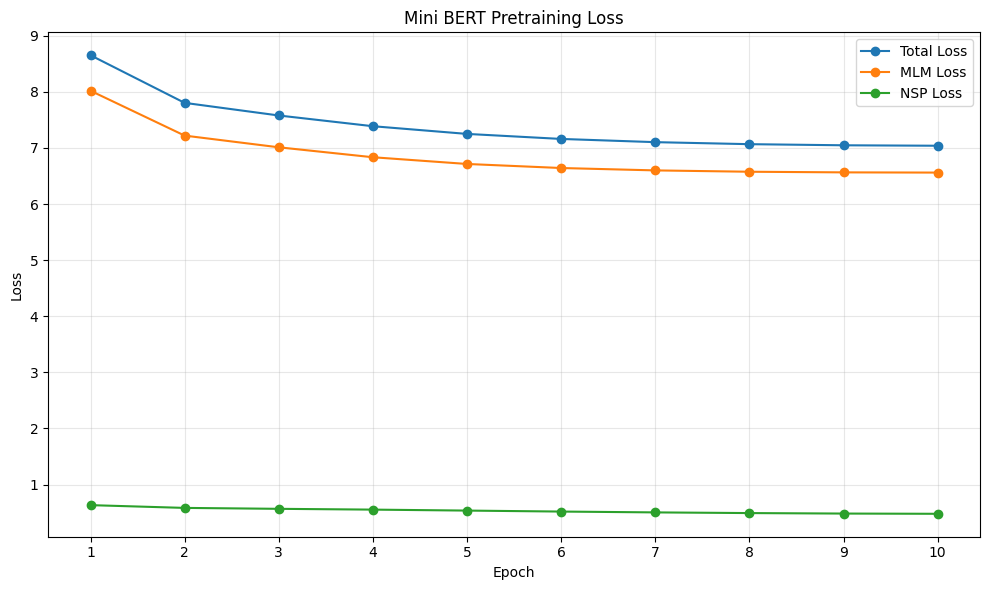

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/GD07/loss_curve.png


In [71]:
# ============================================================
# STEP 8-2. Loss Curve
# ============================================================

LOSS_PLOT_PATH = (
    DRIVE_OUTPUT_DIR
    / "loss_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["total_loss"],
    marker="o",
    label="Total Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["mlm_loss"],
    marker="o",
    label="MLM Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["nsp_loss"],
    marker="o",
    label="NSP Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini BERT Pretraining Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:", LOSS_PLOT_PATH)

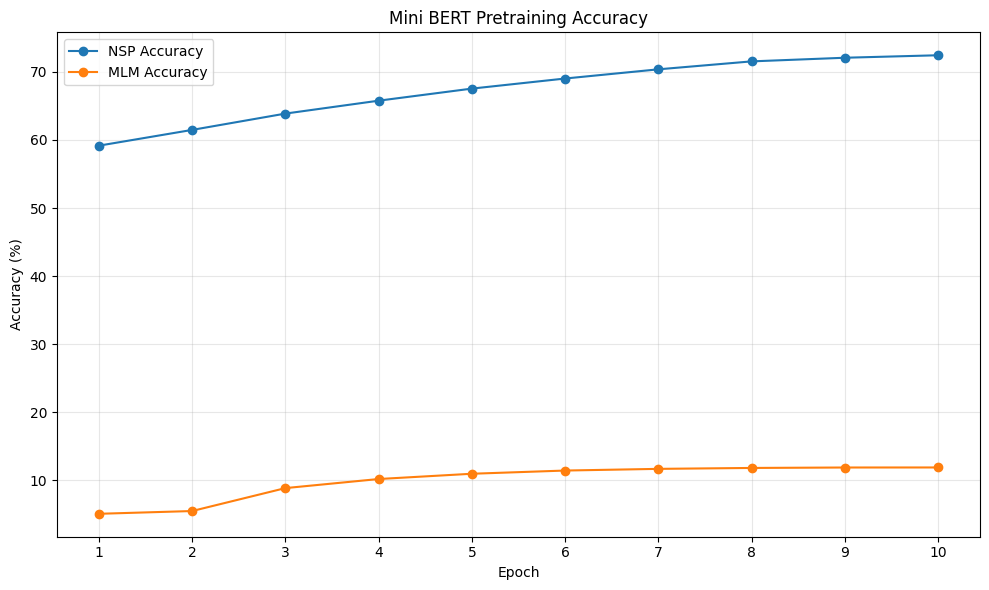

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/GD07/accuracy_curve.png


In [72]:
# ============================================================
# STEP 8-3. Accuracy Curve
# ============================================================

ACC_PLOT_PATH = (
    DRIVE_OUTPUT_DIR
    / "accuracy_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["nsp_acc"] * 100,
    marker="o",
    label="NSP Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["mlm_acc"] * 100,
    marker="o",
    label="MLM Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Mini BERT Pretraining Accuracy")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    ACC_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:", ACC_PLOT_PATH)

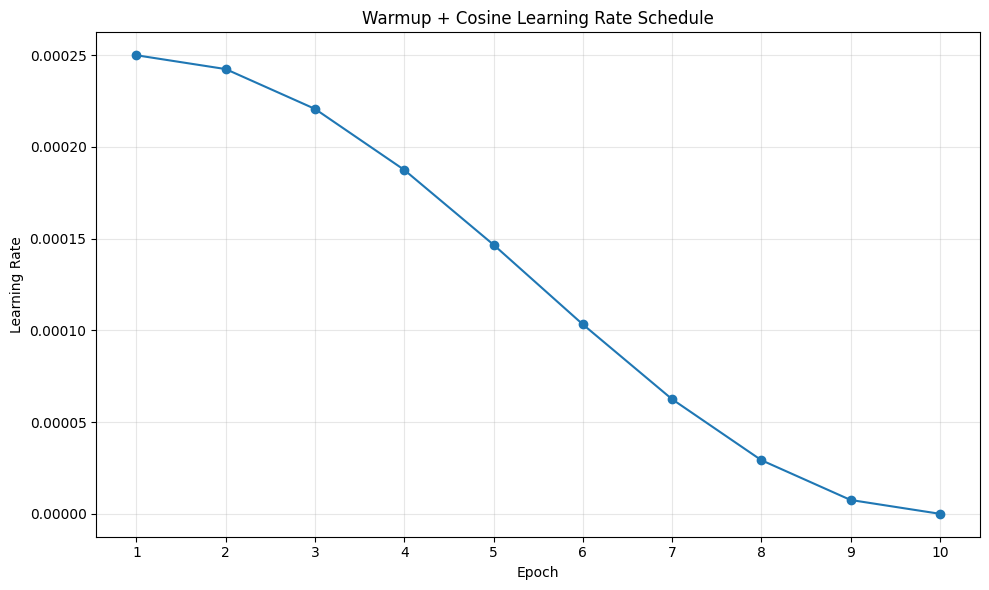

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/GD07/learning_rate_curve.png


In [73]:
# ============================================================
# STEP 8-4. Learning Rate Curve
# ============================================================

LR_PLOT_PATH = (
    DRIVE_OUTPUT_DIR
    / "learning_rate_curve.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["lr"],
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Warmup + Cosine Learning Rate Schedule")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    LR_PLOT_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Saved:", LR_PLOT_PATH)

In [74]:
# ============================================================
# STEP 8-5. Final Result Summary
# ============================================================

first = history_df.iloc[0]
last = history_df.iloc[-1]

summary = {
    "model_parameters":
        trainable_params,

    "epochs":
        EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "training_minutes":
        round(
            training_total_sec / 60,
            2,
        ),

    "total_loss": {
        "epoch_1":
            float(first["total_loss"]),
        "epoch_10":
            float(last["total_loss"]),
    },

    "nsp": {
        "loss_epoch_1":
            float(first["nsp_loss"]),
        "loss_epoch_10":
            float(last["nsp_loss"]),
        "acc_epoch_1":
            float(first["nsp_acc"]),
        "acc_epoch_10":
            float(last["nsp_acc"]),
    },

    "mlm": {
        "loss_epoch_1":
            float(first["mlm_loss"]),
        "loss_epoch_10":
            float(last["mlm_loss"]),
        "acc_epoch_1":
            float(first["mlm_acc"]),
        "acc_epoch_10":
            float(last["mlm_acc"]),
    },
}


SUMMARY_PATH = (
    DRIVE_OUTPUT_DIR
    / "final_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        summary,
        f,
        ensure_ascii=False,
        indent=2,
    )


print(json.dumps(
    summary,
    ensure_ascii=False,
    indent=2,
))

print("\nSaved:", SUMMARY_PATH)

{
  "model_parameters": 1014528,
  "epochs": 10,
  "batch_size": 256,
  "training_minutes": 8.11,
  "total_loss": {
    "epoch_1": 8.651767247200013,
    "epoch_10": 7.039016127586365
  },
  "nsp": {
    "loss_epoch_1": 0.6328869403600693,
    "loss_epoch_10": 0.4785513597726822,
    "acc_epoch_1": 0.5916015625,
    "acc_epoch_10": 0.7243671875
  },
  "mlm": {
    "loss_epoch_1": 8.018880317687989,
    "loss_epoch_10": 6.560464767456055,
    "acc_epoch_1": 0.051013950429712844,
    "acc_epoch_10": 0.11904734103940953
  }
}

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/GD07/final_summary.json


In [75]:
# ============================================================
# STEP 8-6. Artifact Check
# ============================================================

artifacts = {
    "Tokenizer":
        DRIVE_TOKENIZER_MODEL,

    "Dataset manifest":
        DATASET_MANIFEST_PATH,

    "Model config":
        MODEL_CONFIG_PATH,

    "Epoch 5 checkpoint":
        EPOCH5_CKPT_PATH,

    "Epoch 10 checkpoint":
        EPOCH10_CKPT_PATH,

    "Final model":
        FINAL_MODEL_PATH,

    "Training history":
        HISTORY_PATH,

    "Loss plot":
        LOSS_PLOT_PATH,

    "Accuracy plot":
        ACC_PLOT_PATH,

    "Learning-rate plot":
        LR_PLOT_PATH,

    "Final summary":
        SUMMARY_PATH,
}


print("=" * 80)
print("GD07 ARTIFACT CHECK")
print("=" * 80)

for name, path in artifacts.items():

    path = Path(path)

    exists = path.exists()

    if exists:
        size_mb = (
            path.stat().st_size
            / 1024**2
        )

        print(
            f"[OK] {name:24s}"
            f"{size_mb:8.2f} MB  "
            f"{path.name}"
        )

    else:

        print(
            f"[MISSING] "
            f"{name:24s} "
            f"{path}"
        )

GD07 ARTIFACT CHECK
[OK] Tokenizer                   0.34 MB  ko_8000.model
[OK] Dataset manifest            0.00 MB  dataset_manifest.json
[OK] Model config                0.00 MB  mini_bert_config.json
[OK] Epoch 5 checkpoint         11.66 MB  epoch_05.pt
[OK] Epoch 10 checkpoint        11.66 MB  epoch_10.pt
[OK] Final model                 3.89 MB  mini_bert_final.pt
[OK] Training history            0.00 MB  training_history.json
[OK] Loss plot                   0.05 MB  loss_curve.png
[OK] Accuracy plot               0.05 MB  accuracy_curve.png
[OK] Learning-rate plot          0.06 MB  learning_rate_curve.png
[OK] Final summary               0.00 MB  final_summary.json


## 최종 결과 및 해석

본 프로젝트에서는 Korean Wiki corpus를 이용하여
SentencePiece BPE tokenizer와 BERT pretraining dataset을 구성하고,
약 1M parameter 규모의 Mini BERT를 직접 구현하여
10 epoch 동안 pretraining하였다.

### 1. 모델 규모

```text
Trainable Parameters
= 1,014,528
≈ 1.0145M

2. Loss 변화

학습 초기와 최종 epoch을 비교하면 다음과 같다.



```
                Epoch 1       Epoch 10
────────────────────────────────────────
Total Loss       8.6518   →     7.0390
MLM Loss         8.0189   →     6.5605
NSP Loss         0.6329   →     0.4786
```



세 loss 모두 학습 과정에서 지속적으로 감소하였다.

특히 Total Loss는 약 18.6%,
MLM Loss는 약 18.2%,
NSP Loss는 약 24.4% 감소하였다.

따라서 두 pretraining task에 대해
학습이 발산하지 않고 안정적으로 진행되었음을 확인할 수 있었다.

3. Accuracy 변화


```

                Epoch 1       Epoch 10
────────────────────────────────────────
NSP Accuracy      59.16%  →     72.44%
MLM Accuracy       5.10%  →     11.90%
```



NSP는 이진 분류 문제이므로 random baseline이 약 50%이다.
최종 accuracy는 72.44%로 상승하였다.

MLM은 8,007개의 vocabulary 중 원래 token을 예측하는 문제로,
무작위 추측의 기대 정확도는 약 0.0125%이다.

최종 MLM accuracy는 11.90%로 상승하여,
작은 모델임에도 주변 문맥을 이용하여 masked token을
예측하는 표현을 학습했음을 확인하였다.

4. Learning Rate와 후반부 수렴

학습에는 500 step의 warmup과 cosine decay를 적용하였다.



```
5e-7
  │
  │ warmup
  ▼
2.5e-4
  │
  │ cosine decay
  ▼
0
```




Epoch 7 이후 loss와 accuracy의 개선 폭이 작아졌는데,
이 구간은 learning rate 역시 빠르게 감소하는 구간과 일치한다.

따라서 후반부의 완만한 변화는 학습 불안정보다는
scheduler에 따라 parameter update의 크기가 작아진 결과로 해석할 수 있다.

## 전체 실험 흐름


```
Korean Wiki Corpus
        │
        ▼
SentencePiece BPE
  8,007 pieces
        │
        ▼
MLM + NSP
Pretraining Dataset
  128,000 samples
        │
        ▼
np.memmap
        │
        ▼
DataLoader
 batch = 256
        │
        ▼
Mini BERT
1,014,528 parameters
        │
        ▼
Transformer Encoder × 2
        │
    ┌───┴───┐
    ▼       ▼
   MLM     NSP
    │       │
    └───┬───┘
        ▼
   Total Loss
        │
        ▼
 Backpropagation
        │
        ▼
Adam + Warmup
+ Cosine Decay
        │
        ▼
    10 Epochs
        │
        ▼
Loss 감소
Accuracy 증가
```



### 실험의 한계 🕵️‍♀️
현재 MLM
→ 한 번 만든 mask를 10 epoch 반복 사용
→ static masking

현재 NSP
→ A/B 순서 swap으로 FALSE 생성
→ 원 BERT의 random-next 방식과 차이

현재 128K
→ corpus 앞부분부터 목표 수까지 생성
→ 전체 Wiki random sampling 아님